<h1>Задание</h1>

Выбрать модель (или несколько моделей) для обучения. Можно брать предобученные на ImageNet, но нельзя использовать модели, предобученные на задачу распознавания лиц.
Обучить эту модель (модели) на CE loss. Добиться accuracy > 0.7.
Реализовать ArcFace loss.
Обучить модель (модели) на ArcFace loss. Добиться accuracy > 0.7.
Написать небольшой отчет по обучению, сравнить CE loss и ArcFace loss.

<h1>Импорт библиотек</h1>

In [2]:
import pandas as pd
from collections import defaultdict
from tqdm.notebook import tqdm
import random
import cv2
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from torchvision import datasets
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from utils import align_face

<h1>Подготовка данных</h1>

Для начала сделаем словарик вида identity: image_filenames, при этом чтобы у каждого человека было 10+ фоток

In [3]:
identities_dict =  defaultdict(list)

with open('../data/celeba/Anno/identity_CelebA.txt', 'r') as file:
    for line in file:
        image_name, id = line.strip().split()
        identities_dict[int(id)].append(image_name)

identities_dict = {id: images for id, images in identities_dict.items() if len(images) >= 10}

In [4]:
len(identities_dict)

8369

Теперь разобъем на train/val и на query/distractors

In [5]:
random.seed(42)
all_identities = list(identities_dict.keys())
random.shuffle(all_identities)

train_val_id = all_identities[:2000]
query_id = all_identities[2000:2100]
distractor_id = all_identities[2100:2600]

Нужно пройтись по датасету, выровнять фото и сохранить их по папкам

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
os.makedirs('../data/celeba/alligned_img/', exist_ok=True)
shg_model = torch.jit.load("../notebooks/models/shg/shg_final.pt").to(device)
bboxes = pd.read_csv('../data/celeba/Anno/list_bbox_celeba.txt', sep=r'\s+', index_col=0)

In [8]:
def prepare_and_save(image_name, bboxes, model, save_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    image = Image.open(f'../data/celeba/img_celeba/{image_name}').convert('RGB')
    bbox = bboxes.loc[image_name]
    x1, y1, w, h = bbox['x_1'], bbox['y_1'], bbox['width'], bbox['height']
    x2, y2 = x1 + w, y1 + h
    image = image.crop((x1 - 0.2 * w, y1 - 0.2 * h, x2 + 0.2 * w, y2 + 0.2 * h))
    image = transform(image)
    image = align_face(image, model)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, image)

In [9]:
def save_class(image_list, path):
    for image_name in image_list:
        save_path = os.path.join(path, image_name)
        prepare_and_save(image_name, bboxes, shg_model, save_path)

In [ ]:
# for id in train_val_id:
#     images = identities_dict[id]
#     train_img, val_img = train_test_split(images, test_size=0.2, random_state=42)
#     train_path = f'../data/celeba/alligned_img/train/{id}'
#     val_path =f'../data/celeba/alligned_img/val/{id}'
#     os.makedirs(train_path, exist_ok=True)
#     os.makedirs(val_path, exist_ok=True)

#     save_class(train_img, train_path)
#     save_class(val_img, val_path)
        

In [11]:
# for id in query_id:
#     images = identities_dict[id]
#     query_path = f'../data/celeba/alligned_img/query/{id}'
#     os.makedirs(query_path, exist_ok=True)
#     save_class(images, query_path)

# for id in distractor_id:
#     images = identities_dict[id]
#     distractor_path = f'../data/celeba/alligned_img/distractor/{id}'
#     os.makedirs(distractor_path, exist_ok=True)
#     save_class(images, distractor_path)

<h1>Dataloader</h1>

Создадим даталоадер для train, val

In [12]:
transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img/val', transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)

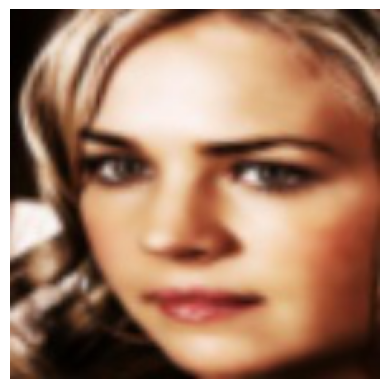

In [13]:
x, y = next(iter(train_loader))
x[0] = x[0]*0.5+0.5
plt.imshow(x[0].permute(1,2,0))
plt.axis('off')
plt.show()

<h1>Подготовка моделей</h1>

<h2>ResNet18</h2>

In [14]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

In [15]:
resnet_18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Надо заменить в последнем слое out features на 1500, и также разморозить предпоследние  слои layer3 и layer4

In [16]:
resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 2000)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

<h2>ResNet50</h2>

Сделаем resnet50 аналогично

In [20]:
resnet_50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device)

In [21]:
resnet_50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [22]:
resnet_50.fc = nn.Linear(resnet_50.fc.in_features, 2000)

for param in resnet_50.parameters():
    param.requires_grad = False

for param in resnet_50.layer4.parameters():
    param.requires_grad = True

for param in resnet_50.fc.parameters():
    param.requires_grad = True

resnet_50 = resnet_50.to(device)

<h1>Обучение</h1>

In [23]:
def train_single_epoch(model, dataloader, optimizer, criterion, metric):
    model.train()
    avg_loss = 0
    avg_score = 0

    for x_batch, y_batch in tqdm(dataloader):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        metric_score = metric(y_pred, y_batch)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        avg_loss += loss.item()
        avg_score += metric_score
    
    avg_loss /= len(dataloader)
    avg_score /= len(dataloader)

    return avg_loss, avg_score

In [24]:
def val_single_epoch(model, dataloader, criterion, metric):
    model.eval()
    avg_loss = 0
    avg_score = 0

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            metric_score = metric(y_pred, y_batch)

            avg_loss += loss.item()
            avg_score += metric_score

    avg_loss /= len(dataloader)
    avg_score /= len(dataloader)

    return avg_loss, avg_score

In [ ]:
def train(model, epochs, train_dataloader, val_dataloader, optimizer, criterion, metric, save_path, scheduler=None, name_postfix=""):
    total_train_loss = []
    total_train_score = []
    total_val_loss = []
    total_val_score = []

    best_score = float('-inf')
    best_epoch = -1
    best_model_state = None
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_score = train_single_epoch(model, train_dataloader, optimizer, criterion, metric)
        val_loss, val_score = val_single_epoch(model, val_dataloader, criterion, metric)
        print(f'Epoch #{epoch}')
        print(f'Train: loss = {train_loss}, {metric.__name__} = {train_score}')
        print(f'Val: loss = {val_loss}, {metric.__name__} = {val_score}')
        if scheduler:
            scheduler.step(val_score)
        if val_score > best_score:
            best_score = val_score
            best_epoch = epoch
            best_model_state = model.state_dict()

        total_train_loss.append(train_loss)
        total_train_score.append(train_score)
        total_val_loss.append(val_loss)
        total_val_score.append(val_score)

        if epoch > 0:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].plot(total_train_loss, label='Train')
            axes[0].plot(total_val_loss, label='Val')
            axes[0].set(xlabel='Epoch', ylabel='Loss')
            axes[1].plot(total_train_score, label='Train')
            axes[1].plot(total_val_score, label='Val')
            axes[1].set(xlabel='Epoch', ylabel=metric.__name__)
            plt.show()

    statistics = {'train loss': total_train_loss,
                  'train_score': total_train_score,
                  'val_loss': total_val_loss,
                  'val_score': total_val_score}
    
    os.makedirs(save_path, exist_ok=True)
    filename = f"weights_{best_score:.2f}".replace(".", "_") + name_postfix + ".pt"
    full_path = os.path.join(save_path, filename)
    torch.save(best_model_state, full_path)

    print(f'Best epoch = {best_epoch}, {metric} = {best_score}')
    
    return model, statistics
         

<h2>ResNet18 CE loss</h2>

<h3>Попытка 1</h3>

In [26]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.7266211711185075, accuracy = 0.031221073217656457
Val: loss = 5.215778137508192, accuracy = 0.10169256847475831


  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.8912602763780404, accuracy = 0.27411671219326267
Val: loss = 3.5125237452356437, accuracy = 0.3118097979323308


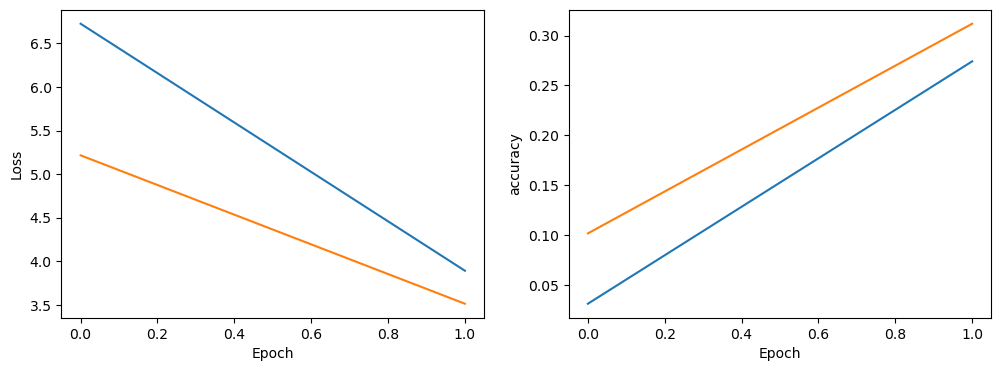

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.030529840731285, accuracy = 0.6016382201067229
Val: loss = 2.7627193739539697, accuracy = 0.4357230968045112


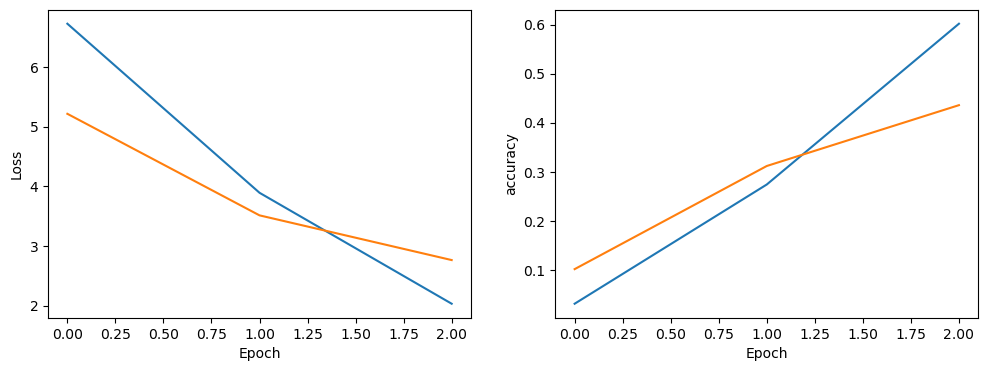

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #3
Train: loss = 0.8587771817831926, accuracy = 0.854749550784086
Val: loss = 2.5029265974697315, accuracy = 0.5036125469924811


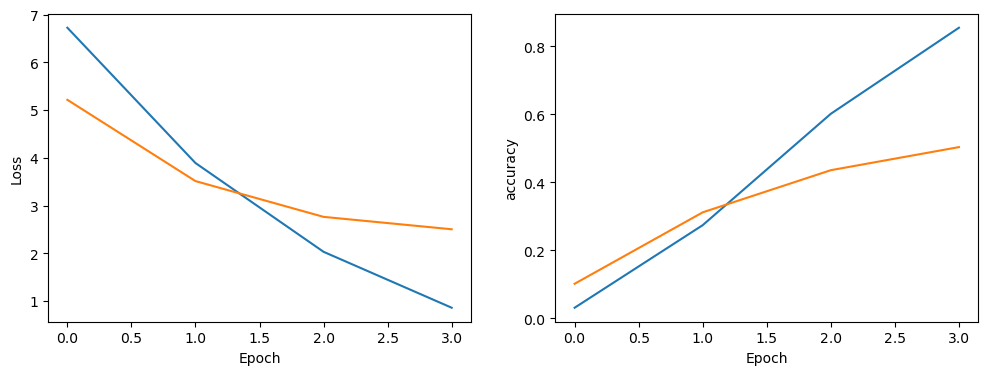

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.24320226068228062, accuracy = 0.9759320663024538
Val: loss = 2.2868185608010543, accuracy = 0.5548826027121375


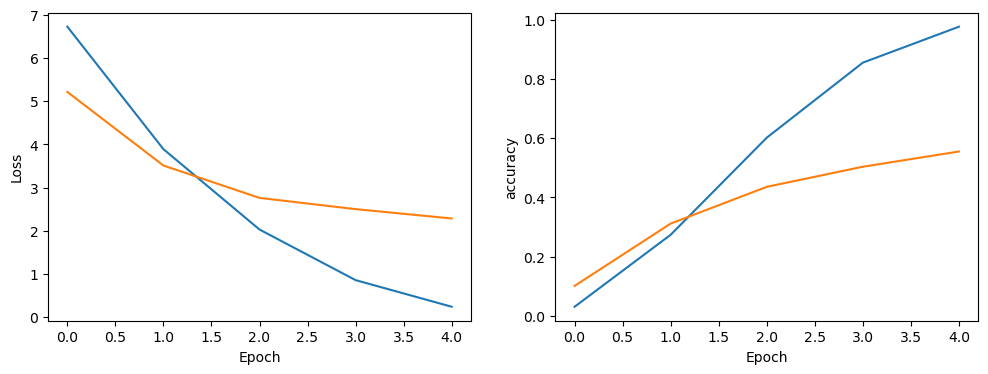

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.06603181305748056, accuracy = 0.9950308325468273
Val: loss = 2.1562334142233195, accuracy = 0.5819032794038668


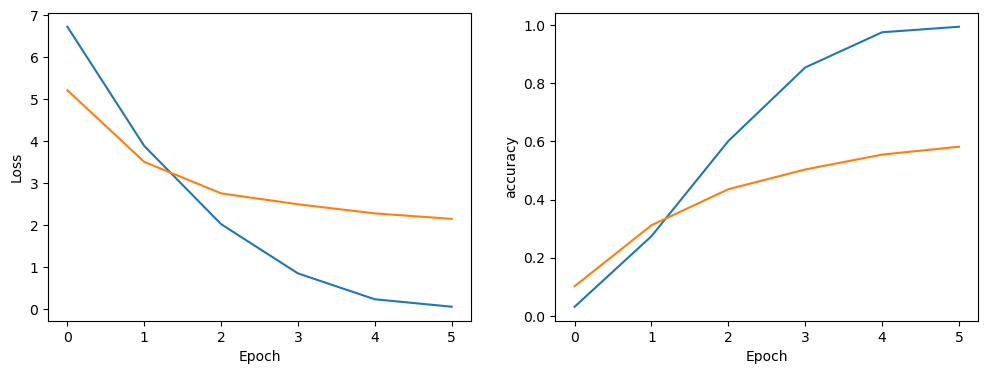

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.03144022305561623, accuracy = 0.9968276962029912
Val: loss = 2.1405865581412065, accuracy = 0.5868521750805585


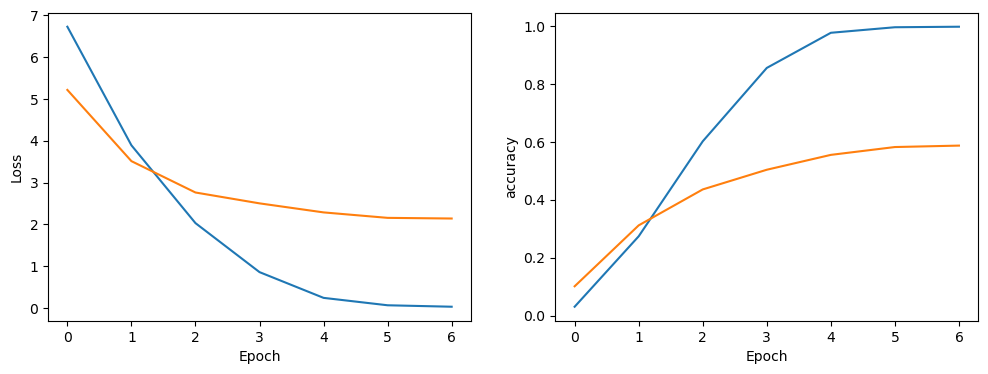

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.022559454513739953, accuracy = 0.9975792253521126
Val: loss = 2.1759644997747323, accuracy = 0.5865437869226637


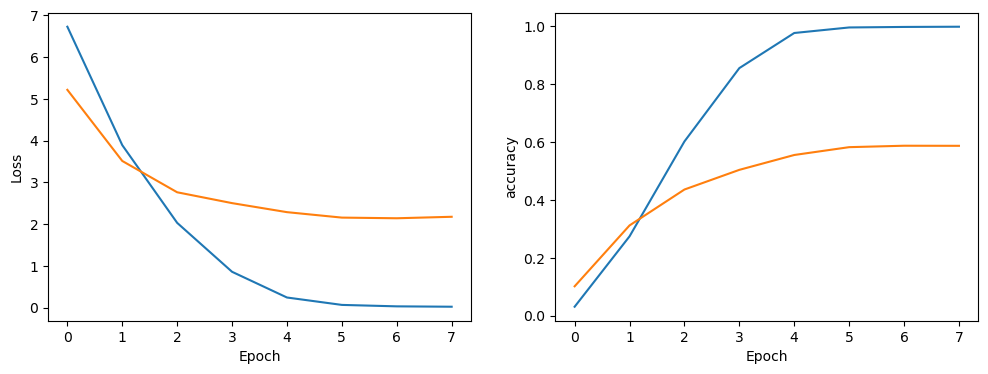

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.016659844109237616, accuracy = 0.9983494718309859
Val: loss = 2.243559216198168, accuracy = 0.568499932867884


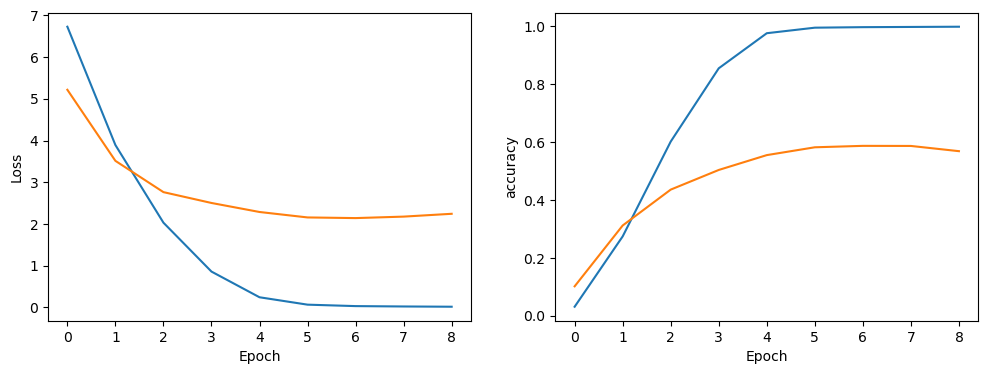

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.014306735591700589, accuracy = 0.9986795774647887
Val: loss = 2.240433096885681, accuracy = 0.5740194515306122


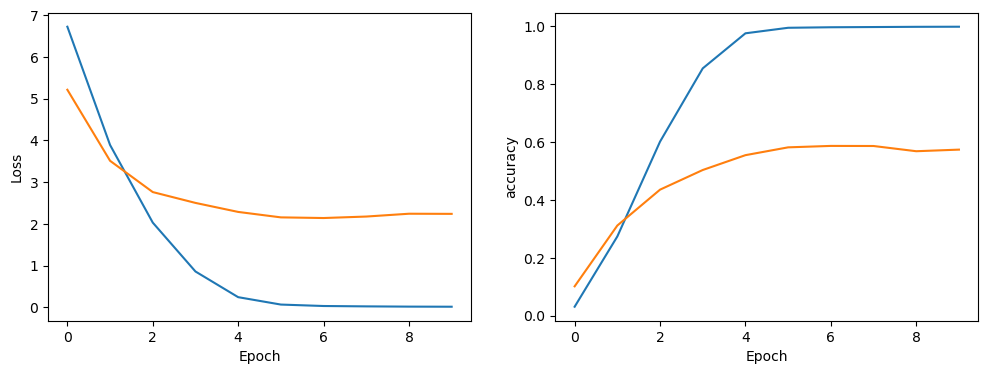

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #10
Train: loss = 0.012667120027710015, accuracy = 0.998899647887324
Val: loss = 2.180449821447071, accuracy = 0.5849787694683136


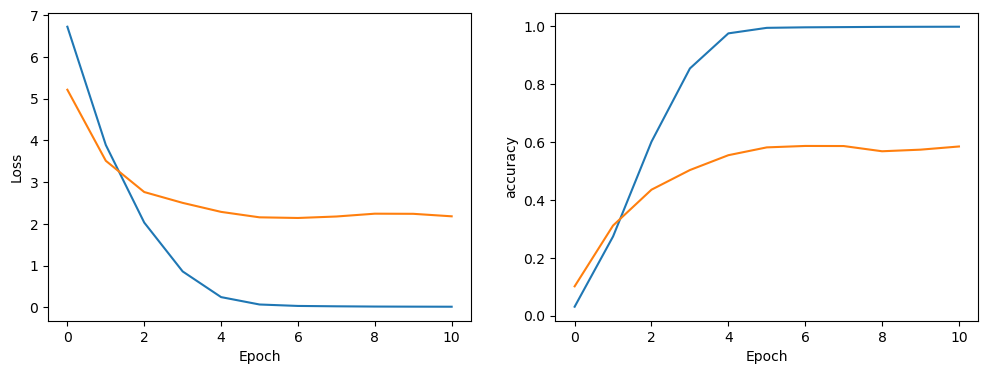

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #11
Train: loss = 0.006686101916810156, accuracy = 0.9997524207746479
Val: loss = 2.0564309923272384, accuracy = 0.6064778296186896


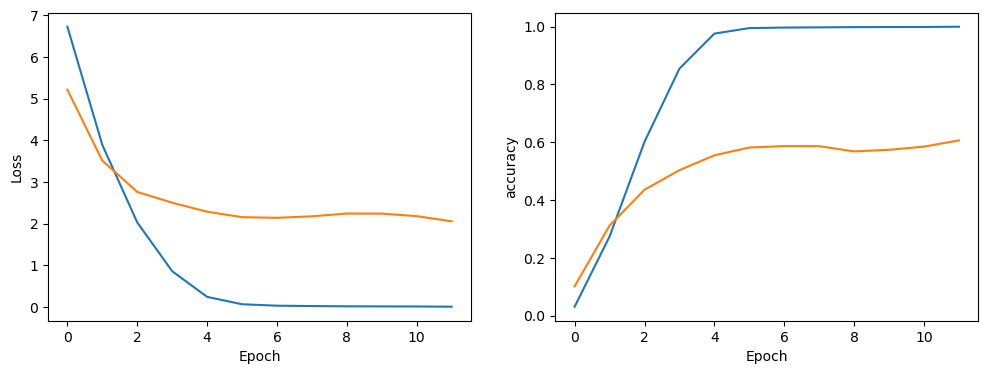

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #12
Train: loss = 0.0044166886634652465, accuracy = 0.9999174735915493
Val: loss = 2.0347689170586434, accuracy = 0.6084938909774437


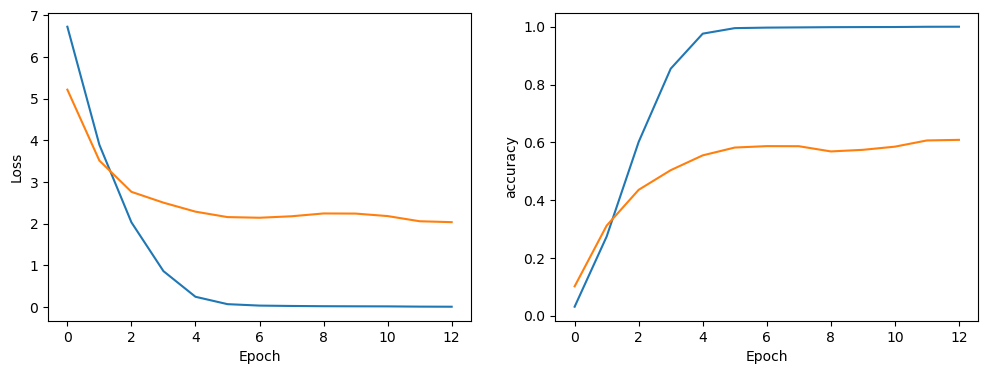

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #13
Train: loss = 0.0037224279572321494, accuracy = 0.9999449823943662
Val: loss = 2.0240377972000525, accuracy = 0.6098617078410311


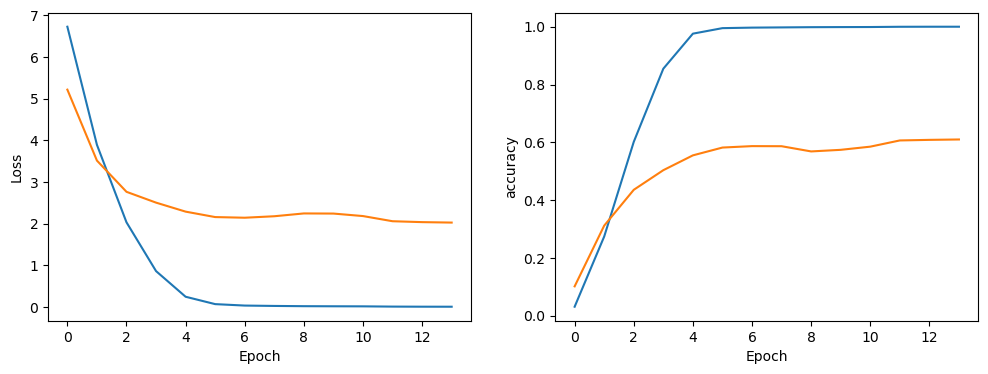

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #14
Train: loss = 0.003339669836068552, accuracy = 0.9999174735915493
Val: loss = 2.020492186671809, accuracy = 0.6112295247046188


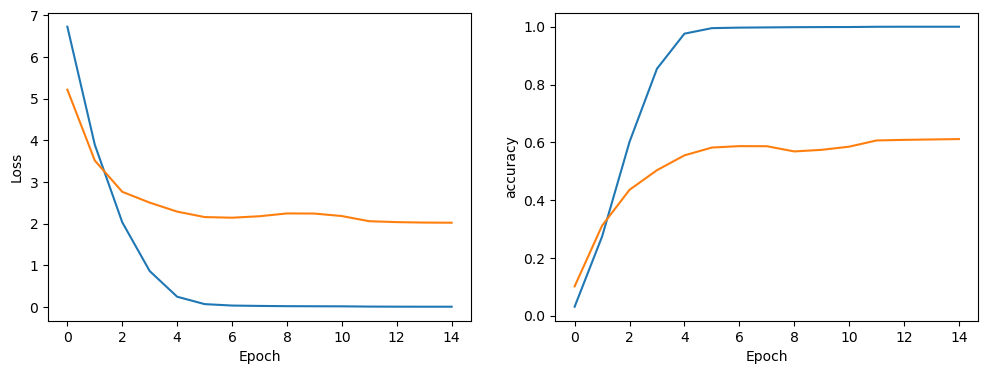

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #15
Train: loss = 0.0030000840943359155, accuracy = 0.9999174735915493
Val: loss = 2.019883946368569, accuracy = 0.6105812802094522


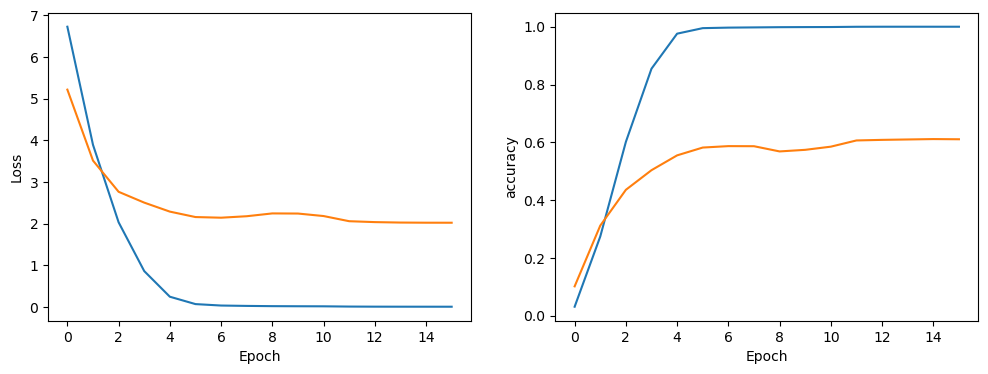

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #16
Train: loss = 0.0026782687120533114, accuracy = 0.9999449823943662
Val: loss = 2.0156447573712, accuracy = 0.6120833613050484


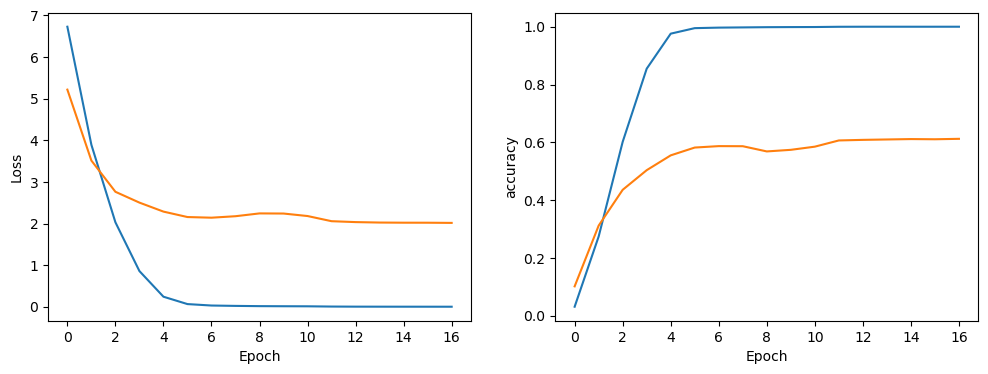

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #17
Train: loss = 0.002485271633445272, accuracy = 0.9999174735915493
Val: loss = 2.014961358747984, accuracy = 0.6125973415682062


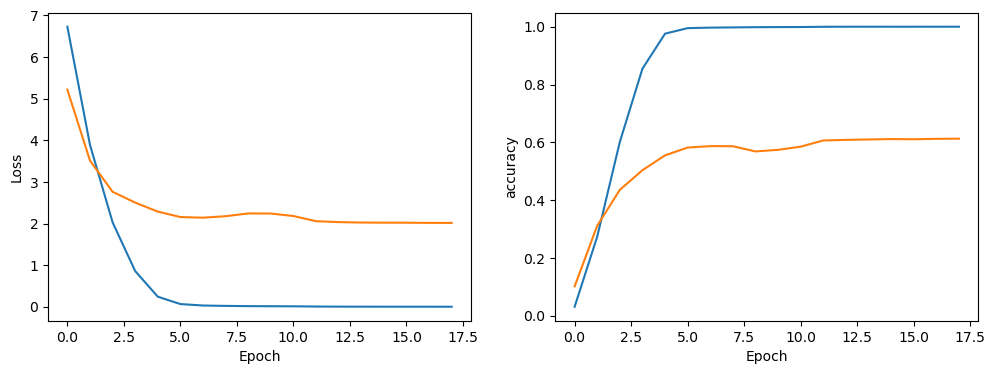

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #18
Train: loss = 0.0022766208448316114, accuracy = 0.9999174735915493
Val: loss = 2.012571171710366, accuracy = 0.6124630773361976


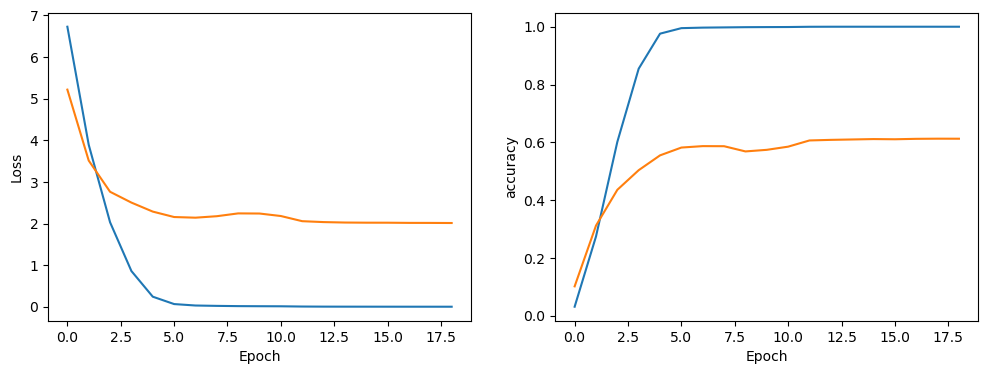

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #19
Train: loss = 0.0020401219166749696, accuracy = 0.9999449823943662
Val: loss = 2.016847434796785, accuracy = 0.6123204215896885


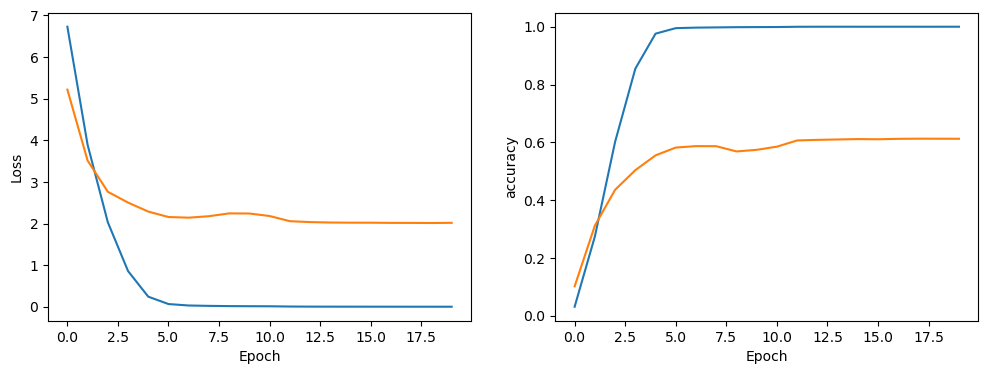

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #20
Train: loss = 0.001856413865822669, accuracy = 0.9999449823943662
Val: loss = 2.0127380302077844, accuracy = 0.6131113218313642


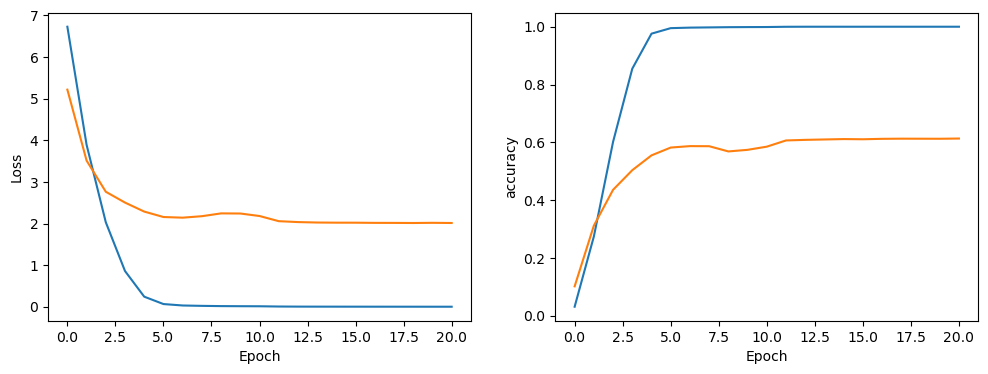

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #21
Train: loss = 0.0017593929299783014, accuracy = 0.9999449823943662
Val: loss = 2.0159502029418945, accuracy = 0.6126686694414608


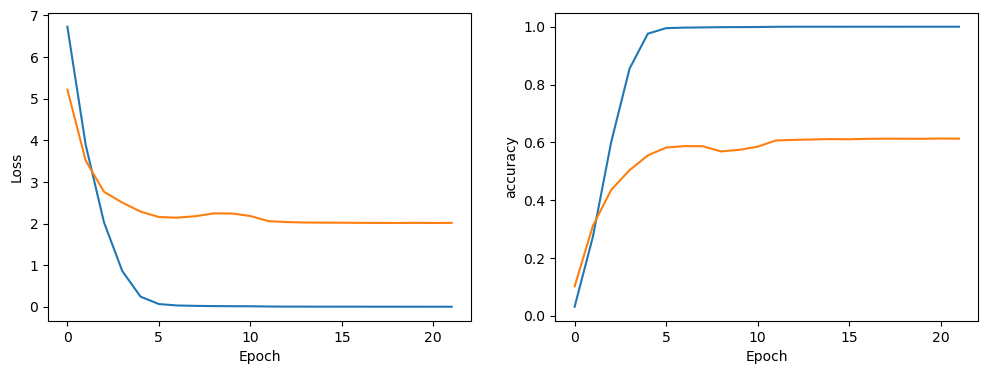

  0%|          | 0/142 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
resnet_18, resnet18_stats = train(resnet_18, 39, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_1')

<h3>Попытка 2</h3>

Прекрасно видно, что модель переобучилась. Пробуем заморозить layer4, оставим только последний слой

In [29]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 2000)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #0
Train: loss = 7.511322464741451, accuracy = 0.008902926255989546
Val: loss = 6.8586023732235555, accuracy = 0.030790564581095595


  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #1
Train: loss = 6.094313752483314, accuracy = 0.10076446112240453
Val: loss = 6.196476032859401, accuracy = 0.08800600832438238


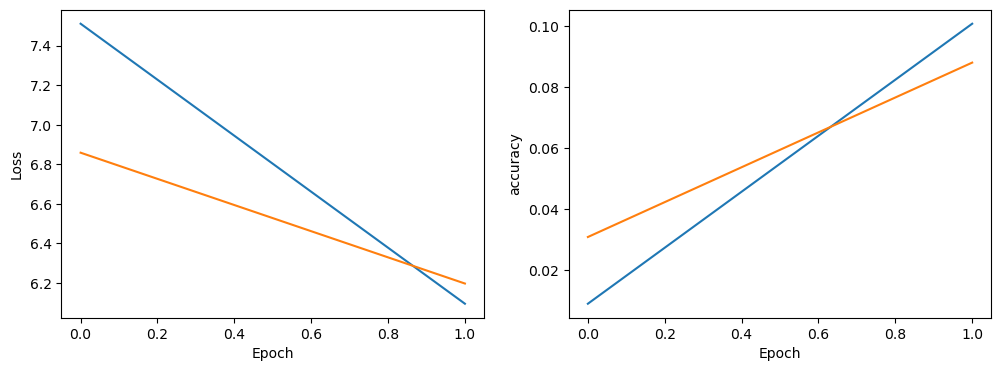

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #2
Train: loss = 5.149004795181919, accuracy = 0.22367577727965732
Val: loss = 5.755774171728837, accuracy = 0.12755731404403867


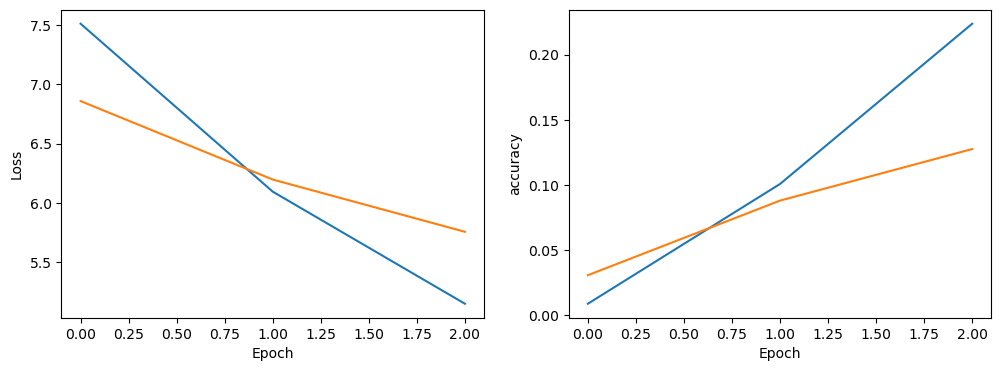

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #3
Train: loss = 4.412889695503343, accuracy = 0.3330275224154204
Val: loss = 5.43437227449919, accuracy = 0.157296841433942


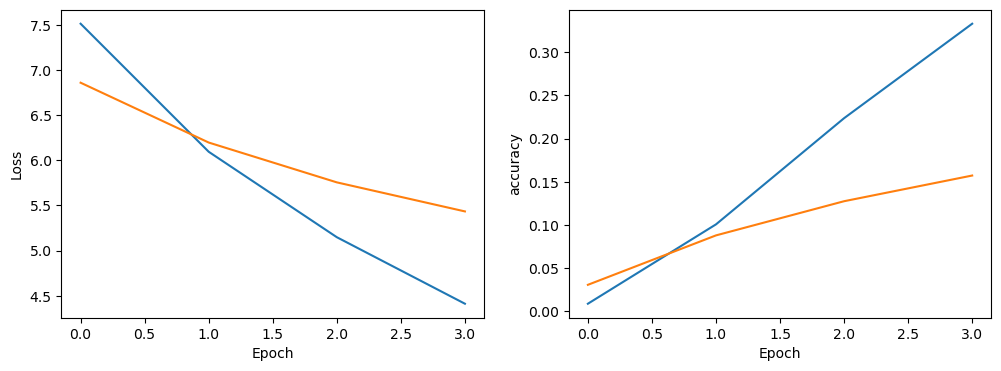

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #4
Train: loss = 3.830929529499, accuracy = 0.4230371760200377
Val: loss = 5.218970524637323, accuracy = 0.18208537526852844


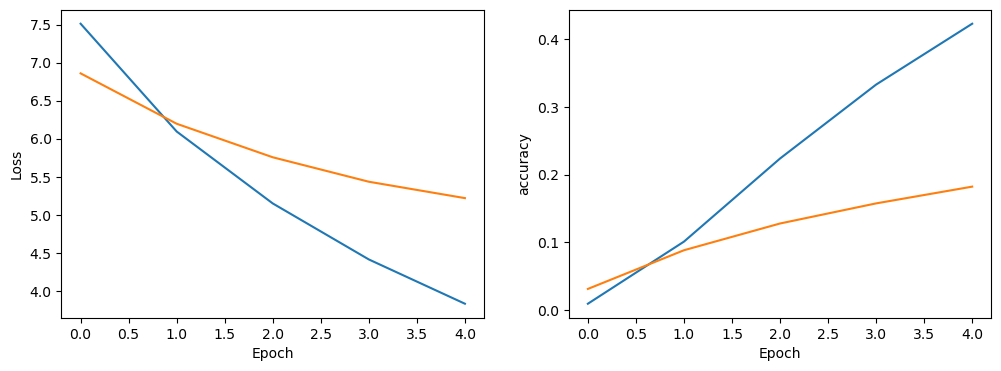

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #5
Train: loss = 3.35999102491728, accuracy = 0.496432647106868
Val: loss = 5.041766806652672, accuracy = 0.20124320287325456


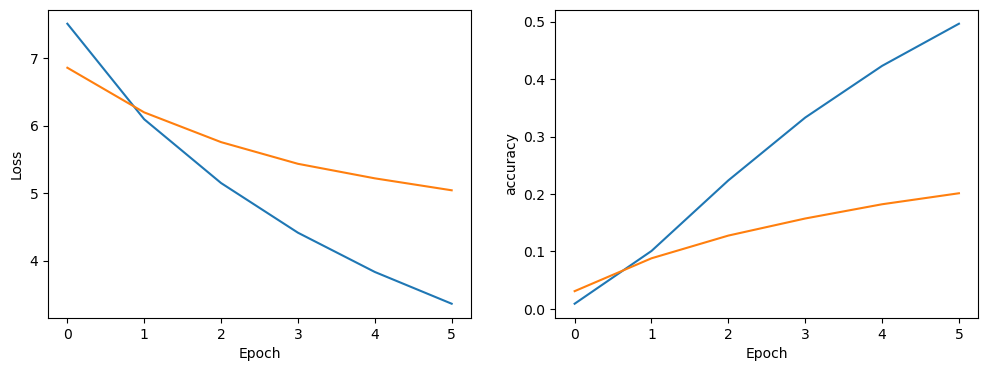

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #6
Train: loss = 2.9751010125791524, accuracy = 0.5561298687745027
Val: loss = 4.914444183048449, accuracy = 0.2127563607679914


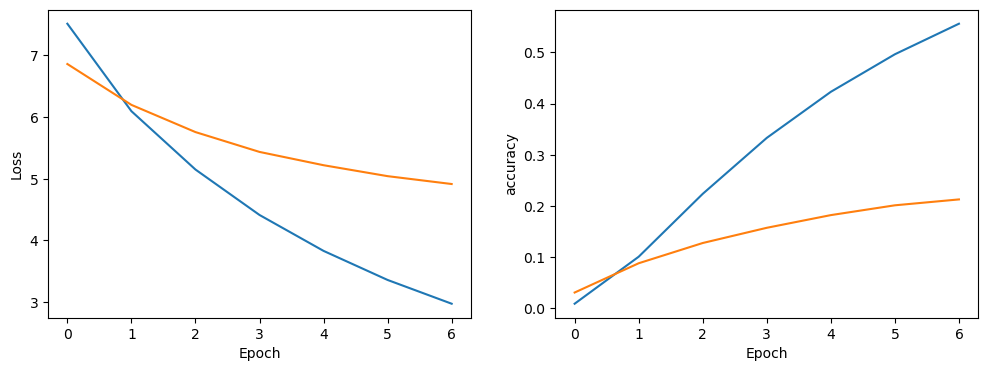

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #7
Train: loss = 2.6594619767766603, accuracy = 0.6038202070023233
Val: loss = 4.806504789151643, accuracy = 0.2242863016917293


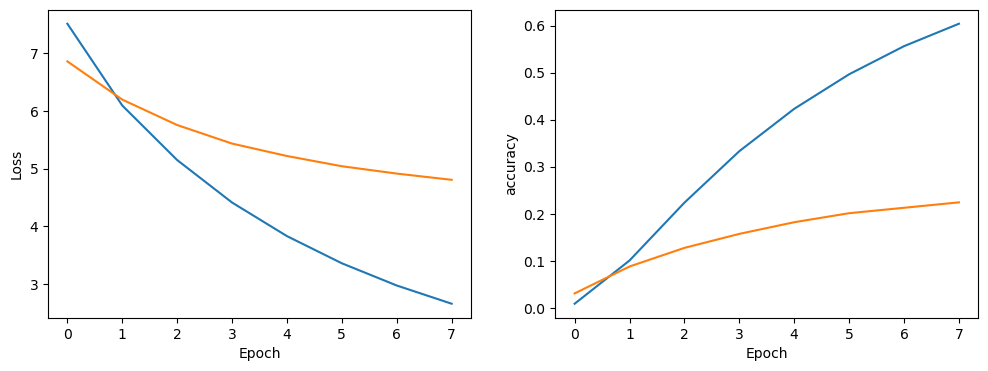

  0%|          | 0/142 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
resnet_18, resnet18_stats = train(resnet_18, 30, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_2')

Опять val лосс не растет, попробуем немного поменять датасет, брать Identities не с 10+ фото, а побольше

<h3>Попытка 3</h3>

In [62]:
identities_dict =  defaultdict(list)

with open('../data/celeba/Anno/identity_CelebA.txt', 'r') as file:
    for line in file:
        image_name, id = line.strip().split()
        identities_dict[int(id)].append(image_name)

identities_dict = {id: images for id, images in identities_dict.items() if len(images) >= 25}

len(identities_dict)

3661

In [63]:
random.seed(42)
all_identities = list(identities_dict.keys())
random.shuffle(all_identities)

train_val_id = all_identities[:2000]
query_id = all_identities[2000:2100]
distractor_id = all_identities[2100:2600]

Отлично, подходит

In [64]:
# os.makedirs('../data/celeba/alligned_img25/', exist_ok=True)

# for id in train_val_id:
#     images = identities_dict[id]
#     train_img, val_img = train_test_split(images, test_size=0.2, random_state=42)
#     train_path = f'../data/celeba/alligned_img25/train/{id}'
#     val_path =f'../data/celeba/alligned_img25/val/{id}'
#     os.makedirs(train_path, exist_ok=True)
#     os.makedirs(val_path, exist_ok=True)

#     save_class(train_img, train_path)
#     save_class(val_img, val_path)
        

In [ ]:
transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img25/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img25/val', transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)

In [65]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 2000)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [66]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.486771090913214, accuracy = 0.04263705907352316
Val: loss = 4.8787633510346105, accuracy = 0.13502327127659575


  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.584272335906055, accuracy = 0.317682878240544
Val: loss = 3.281440481226495, accuracy = 0.3522440159574468


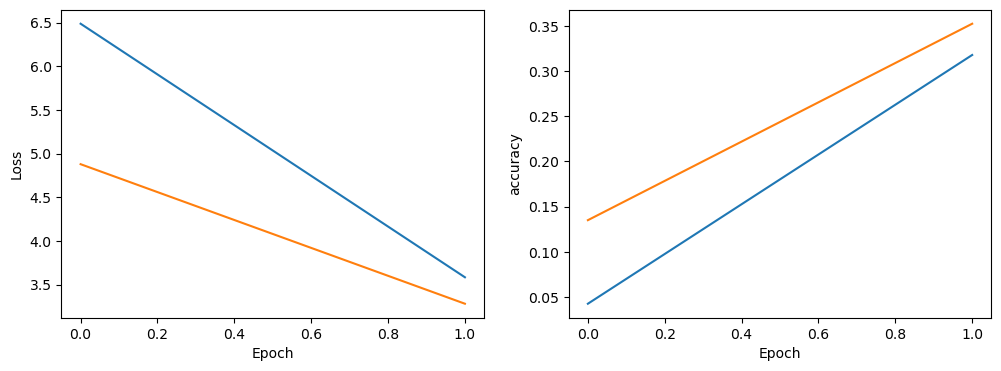

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #2
Train: loss = 1.8941840960834566, accuracy = 0.6227388130400907
Val: loss = 2.7027052717005953, accuracy = 0.4548038563829787


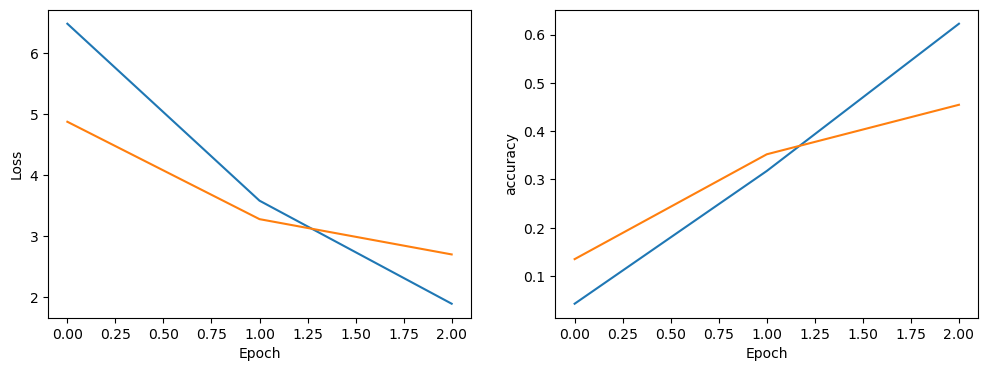

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #3
Train: loss = 0.8418481336772771, accuracy = 0.843787518593285
Val: loss = 2.467454862087331, accuracy = 0.5155418882978723


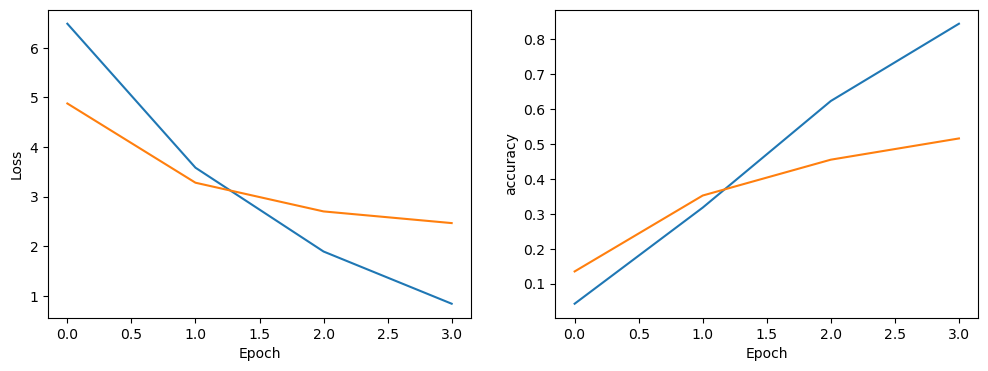

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.24894027930596915, accuracy = 0.9699261359611843
Val: loss = 2.3590250953714897, accuracy = 0.5439827127659574


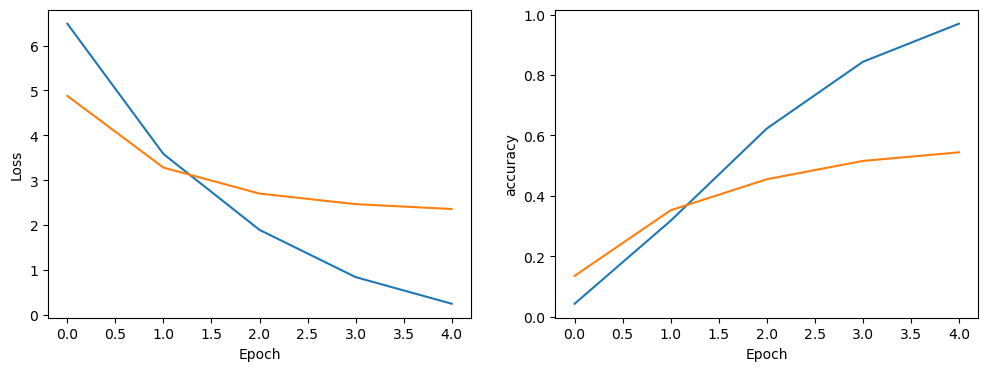

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.07661369919406445, accuracy = 0.9923034866836663
Val: loss = 2.1588245807810034, accuracy = 0.5827626329787234


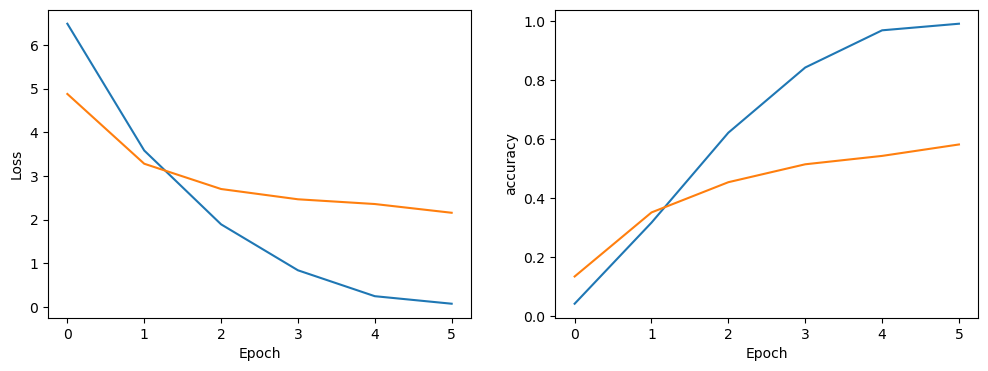

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.04073750704156431, accuracy = 0.9948501027057657
Val: loss = 2.1582663718690265, accuracy = 0.5883311170212766


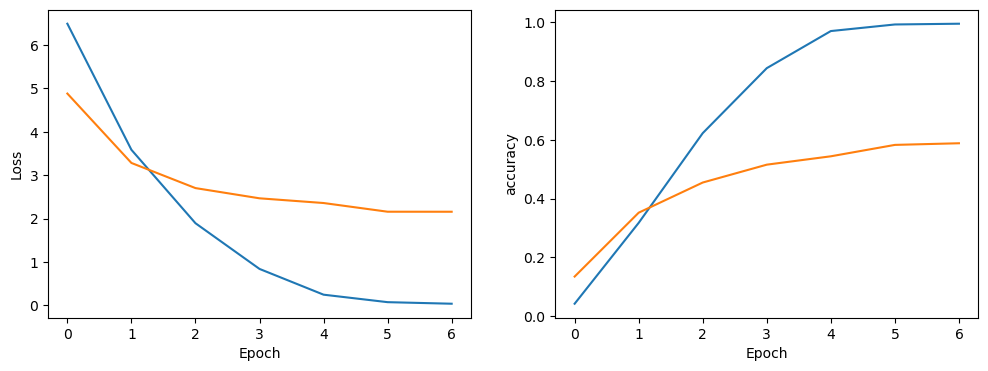

  0%|          | 0/181 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_3')

<h3>Попытка 4</h3>

Лучше по сравнению с попыткой 1 не стало, попробуем добавить аугментаций

In [73]:
transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # нормализация из ImageNet
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img25/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img25/val', transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)

In [74]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 2000)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [75]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.636071099760783, accuracy = 0.03057433329791755
Val: loss = 5.140644814105744, accuracy = 0.0948969414893617


  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.9916639222624553, accuracy = 0.24382005684232894
Val: loss = 3.5586356051424715, accuracy = 0.3028590425531915


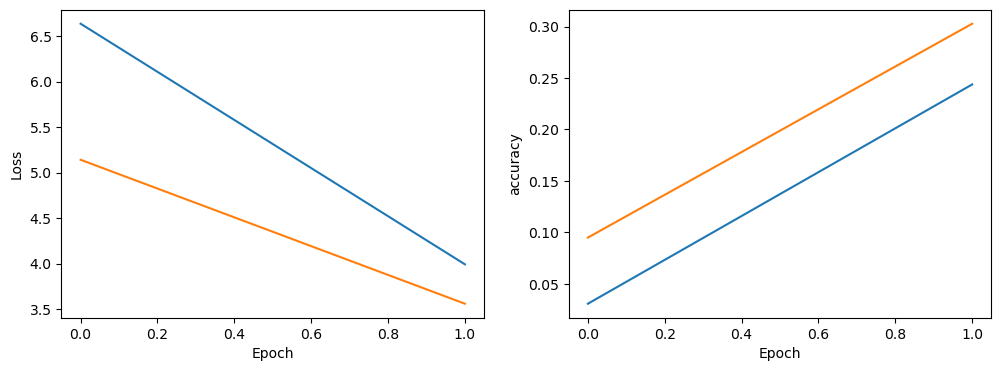

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.472399255188789, accuracy = 0.49482520098455873
Val: loss = 2.7911159966854338, accuracy = 0.4332945478723404


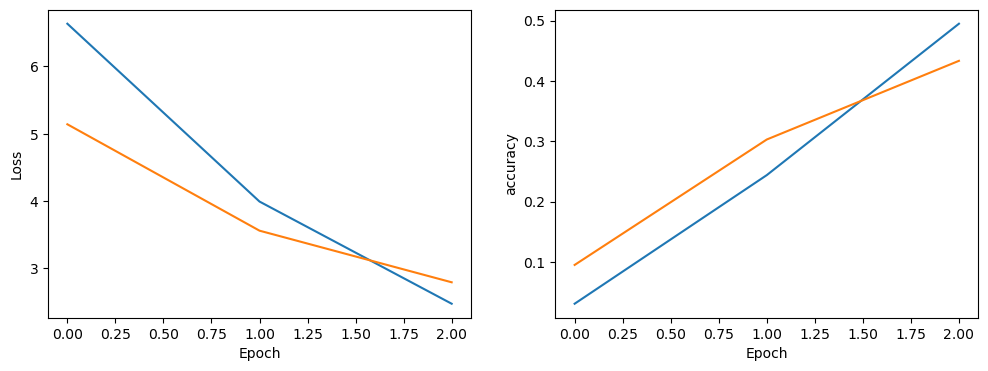

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.6119603807754939, accuracy = 0.6611039541719791
Val: loss = 2.446319709432886, accuracy = 0.5013630319148936


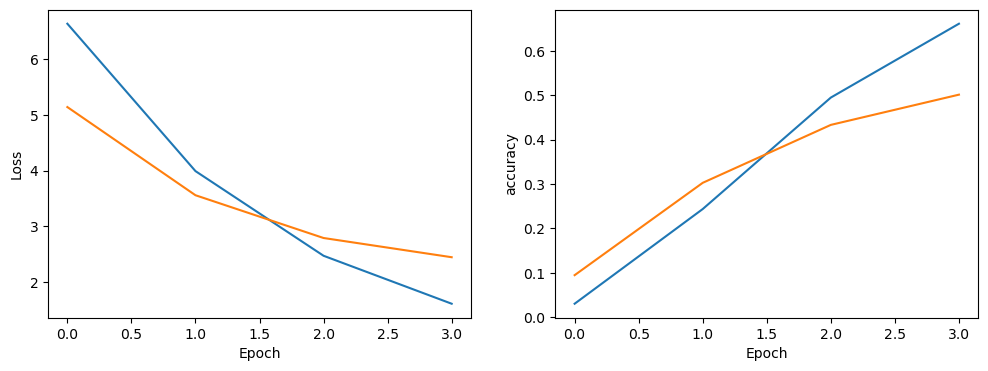

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #4
Train: loss = 1.0706041139133728, accuracy = 0.7710969595551778
Val: loss = 2.262129502093538, accuracy = 0.5410405585106383


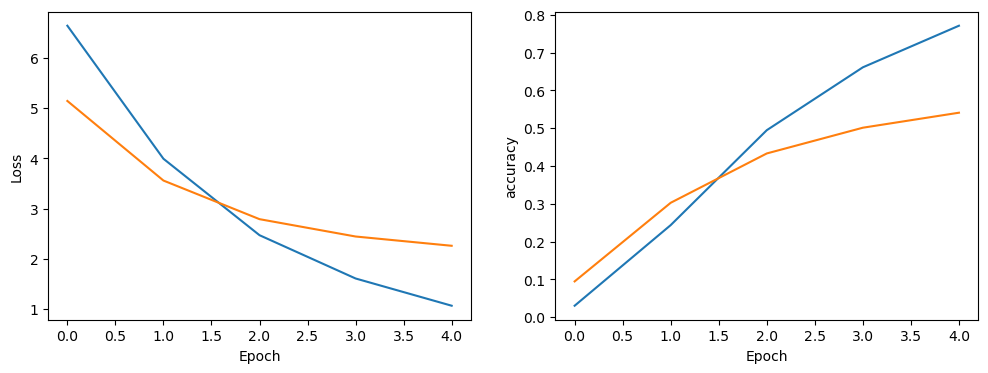

  0%|          | 0/181 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_4')

<h3>Попытка 5</h3>

Добавим дропаут на последний слой

In [77]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Sequential(
    nn.BatchNorm1d(512),  
    nn.Dropout(0.5),
    nn.Linear(512, 2000)
)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [78]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.443334708556286, accuracy = 0.04109536584502054
Val: loss = 4.949106987486494, accuracy = 0.16557513297872342


  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #1
Train: loss = 4.036482691106217, accuracy = 0.2626512917906219
Val: loss = 3.3025770542469433, accuracy = 0.3962433510638298


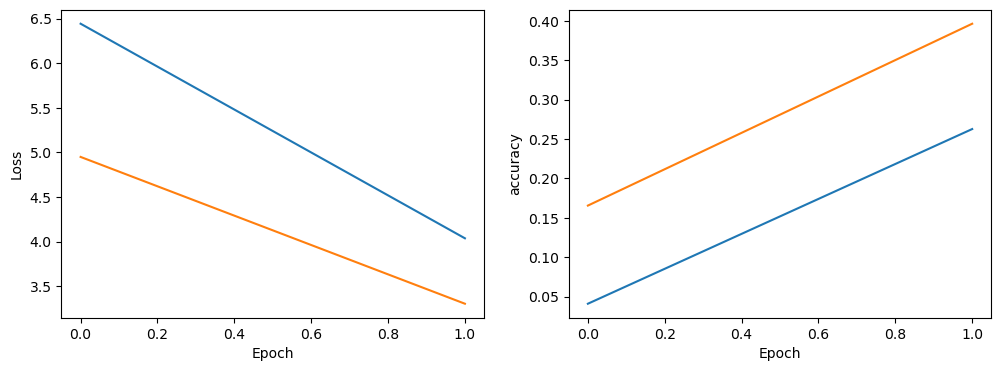

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.550967405514164, accuracy = 0.49968513156962746
Val: loss = 2.5514973275204924, accuracy = 0.511968085106383


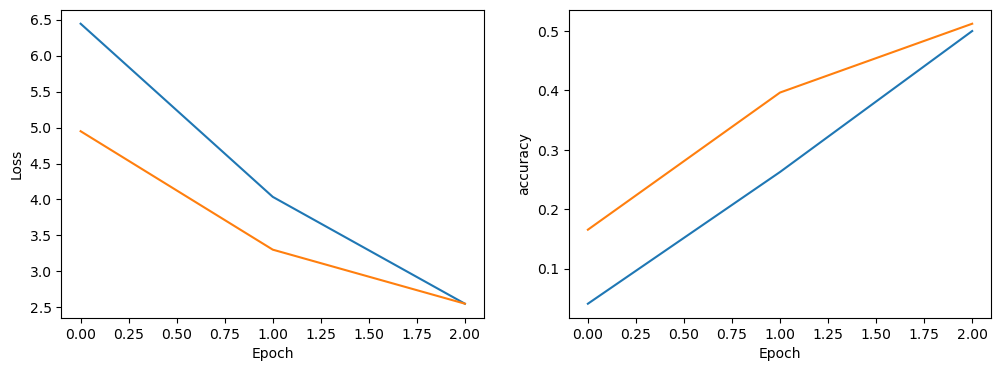

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.727041042970689, accuracy = 0.6431698452330359
Val: loss = 2.130313421817536, accuracy = 0.5857047872340425


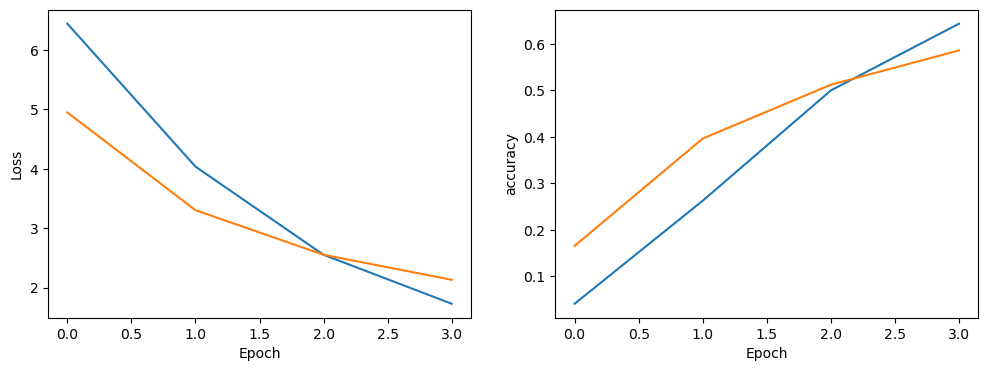

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #4
Train: loss = 1.224004180391849, accuracy = 0.7375201427255984
Val: loss = 1.9800018706220261, accuracy = 0.6076628989361702


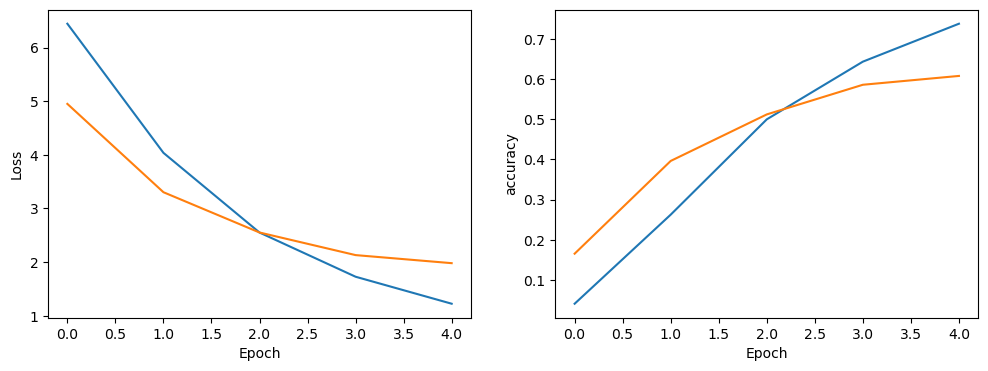

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.8987339310224544, accuracy = 0.8008334882773764
Val: loss = 1.8965904433676537, accuracy = 0.6276429521276596


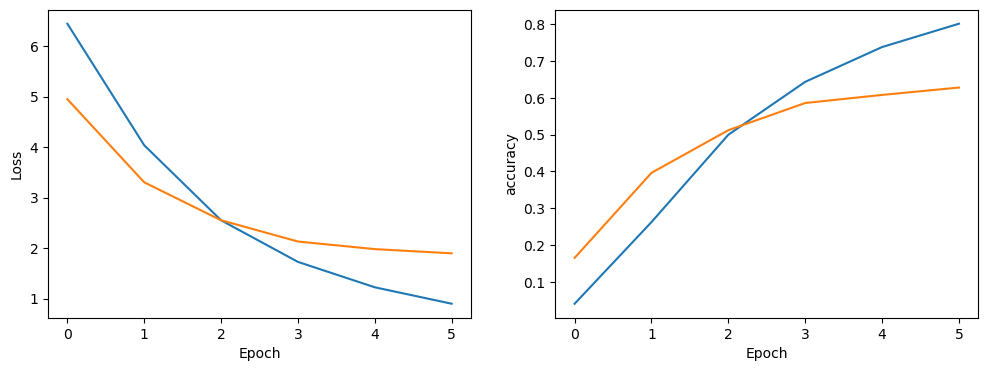

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.6723983197251736, accuracy = 0.8458337760305992
Val: loss = 1.9297903243531571, accuracy = 0.6256648936170213


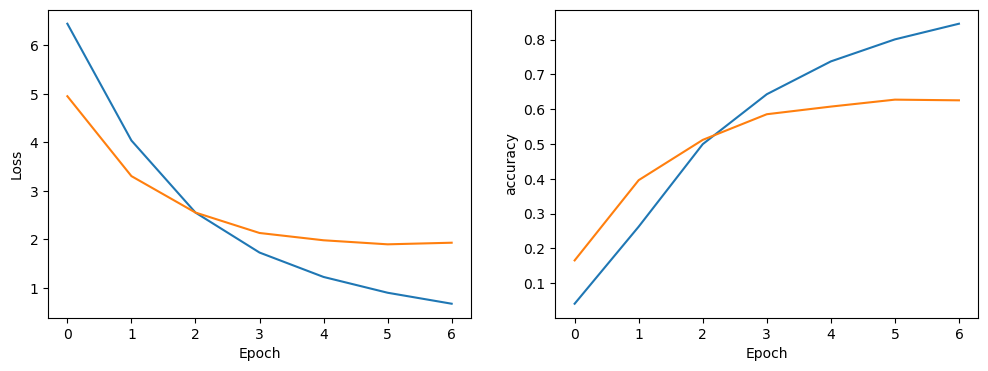

  0%|          | 0/181 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_5')

Добавилось пару процентов, но до 0.7 не дотягивает, попробуем разморозить ещё один слой

<h3>Попытка 6</h3>

In [80]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Sequential(
    nn.BatchNorm1d(512),  
    nn.Dropout(0.5),
    nn.Linear(512, 2000)
)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer3.parameters():
    param.requires_grad = True

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [81]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.50518602034005, accuracy = 0.03296312774472305
Val: loss = 5.119569616114839, accuracy = 0.12054521276595745


  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #1
Train: loss = 4.134587208869049, accuracy = 0.23424185879728007
Val: loss = 3.329636497700468, accuracy = 0.3768783244680851


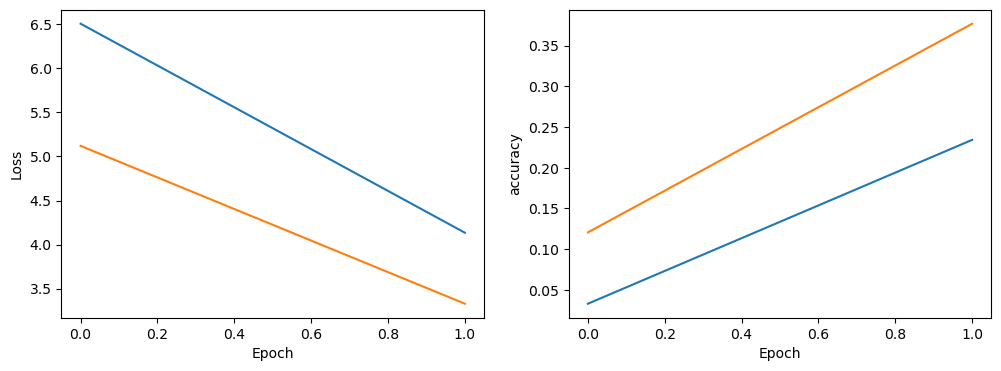

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.544888769065478, accuracy = 0.48941898197336736
Val: loss = 2.4887174697632486, accuracy = 0.5027260638297872


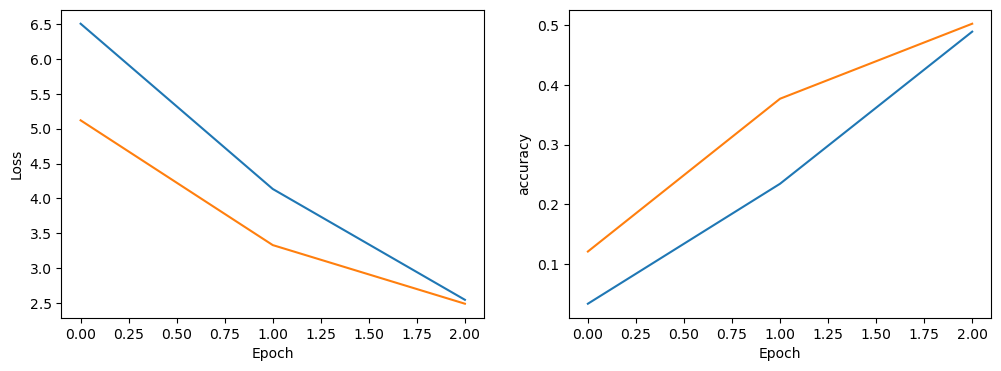

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.6496469757174919, accuracy = 0.6560337423856071
Val: loss = 2.019795006894051, accuracy = 0.5924534574468084


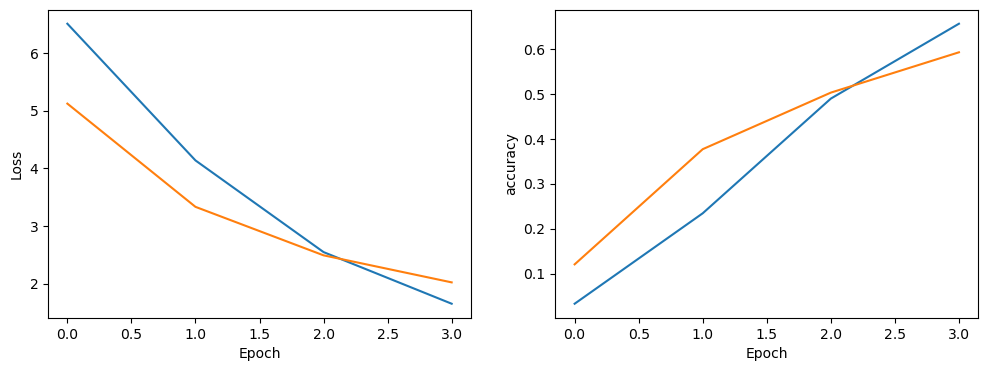

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #4
Train: loss = 1.1491005562287009, accuracy = 0.7532179664258393
Val: loss = 1.9296397249749366, accuracy = 0.6112699468085107


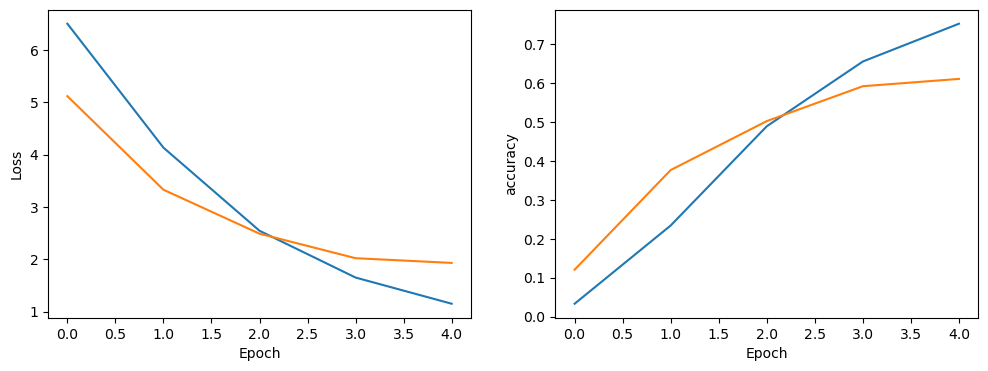

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.8324242300091528, accuracy = 0.8158151384757047
Val: loss = 1.7419475672092843, accuracy = 0.6479886968085107


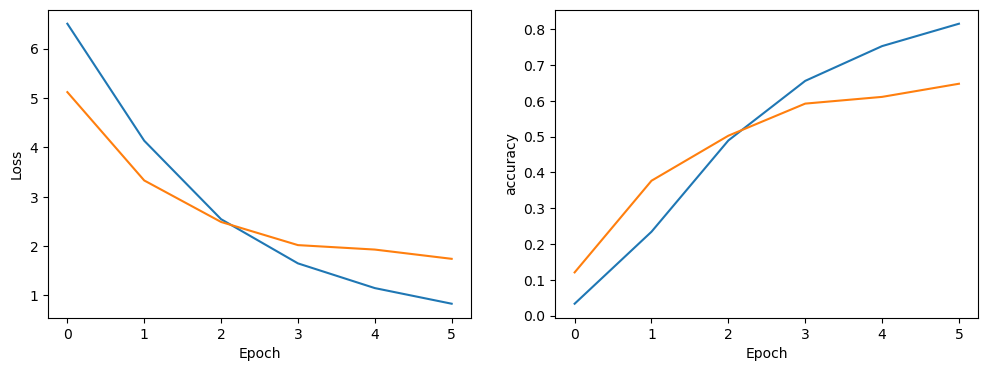

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.6082427676211405, accuracy = 0.8637571495608443
Val: loss = 1.6089145312917994, accuracy = 0.6831615691489361


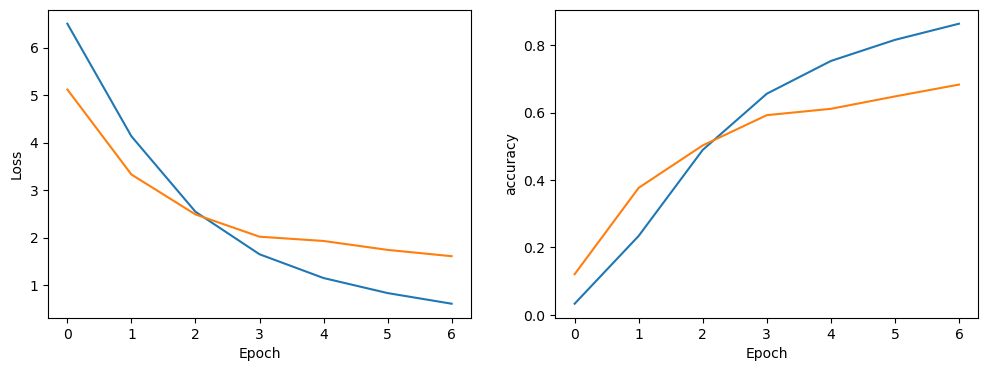

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.45851564308556403, accuracy = 0.8940886634084148
Val: loss = 1.5940556259865457, accuracy = 0.6886303191489362


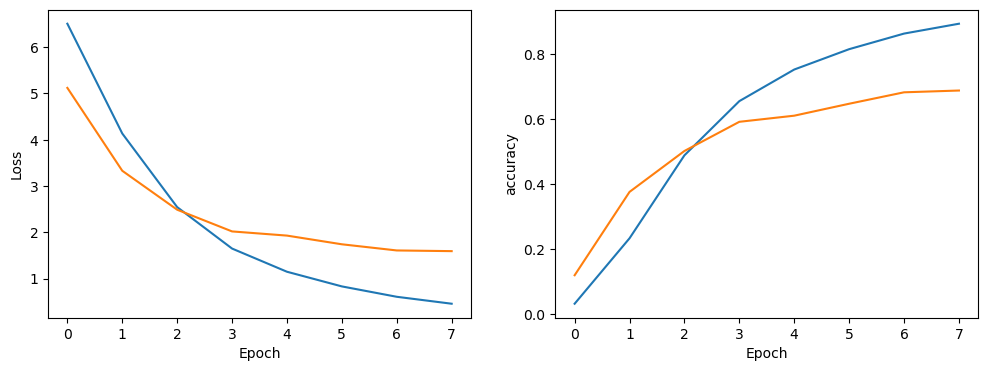

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.36527849684433383, accuracy = 0.9119609054044482
Val: loss = 1.5483233700407313, accuracy = 0.7071309840425533


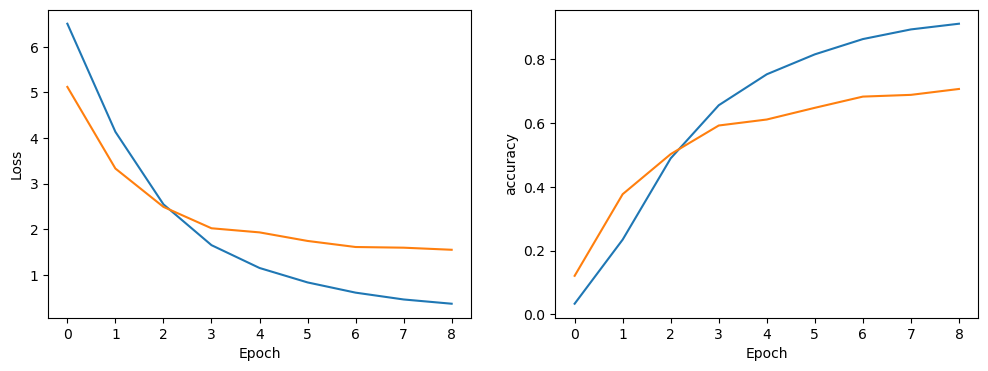

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.2902699149115968, accuracy = 0.9289023763989234
Val: loss = 1.6940779089927673, accuracy = 0.6921376329787233


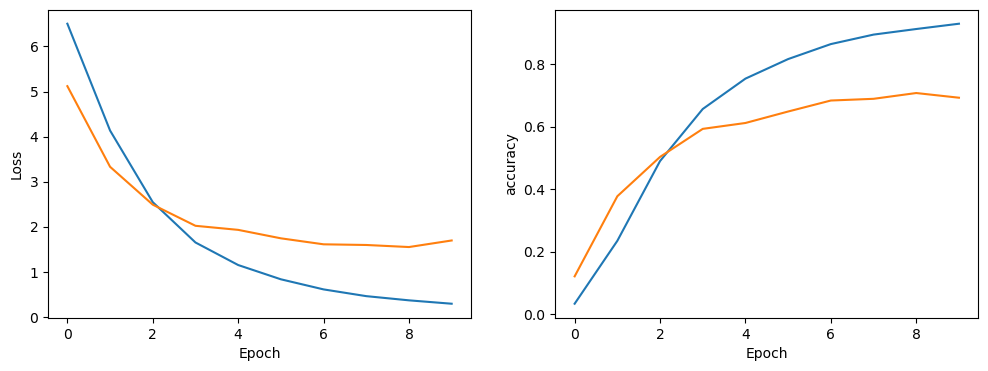

Best epoch = 8, <function accuracy at 0x0000024B2918F6A0> = 0.7071309840425533


In [ ]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_6')

Ура, accuracy 0.7 достигнута, но еле еле, попробуем ещё улучшить

<h3>Попытка 7</h3>

Гипотеза - слишком много классов и слишком мало экземпляров в каждом классе, модель достаточно умная и поэтому она переучивается

Также уменьшим batch size

In [89]:
identities_dict =  defaultdict(list)

with open('../data/celeba/Anno/identity_CelebA.txt', 'r') as file:
    for line in file:
        image_name, id = line.strip().split()
        identities_dict[int(id)].append(image_name)

identities_dict = {id: images for id, images in identities_dict.items() if len(images) >= 30}

print(len(identities_dict))

2360


In [90]:
random.seed(42)
all_identities = list(identities_dict.keys())
random.shuffle(all_identities)

train_val_id = all_identities[:1000]
query_id = all_identities[1000:1100]
distractor_id = all_identities[1100:1600]

In [ ]:
os.makedirs('../data/celeba/alligned_img_30_1000/', exist_ok=True)

In [ ]:
# for id in train_val_id:
#     images = identities_dict[id]
#     train_img, val_img = train_test_split(images, test_size=0.2, random_state=42)
#     train_path = f'../data/celeba/alligned_img_30_1000/train/{id}'
#     val_path =f'../data/celeba/alligned_img_30_1000/val/{id}'
#     os.makedirs(train_path, exist_ok=True)
#     os.makedirs(val_path, exist_ok=True)

#     save_class(train_img, train_path)
#     save_class(val_img, val_path)

In [93]:
transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # нормализация из ImageNet
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img_30_1000/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img_30_1000/val', transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

In [94]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Sequential(
    nn.BatchNorm1d(512),  
    nn.Dropout(0.5),
    nn.Linear(512, 1000)
)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer3.parameters():
    param.requires_grad = True

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [98]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #0
Train: loss = 5.737304170080956, accuracy = 0.058432946924144316
Val: loss = 4.206695805204675, accuracy = 0.2210179633970429


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.3889862666738795, accuracy = 0.3333580259404872
Val: loss = 2.6776805177648018, accuracy = 0.4608557969707897


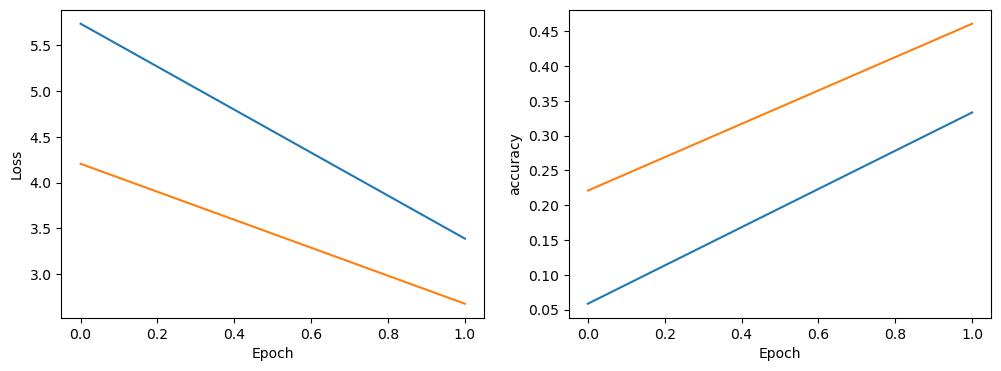

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.039719911965918, accuracy = 0.5729323253931545
Val: loss = 2.0307281955759575, accuracy = 0.5736820456184637


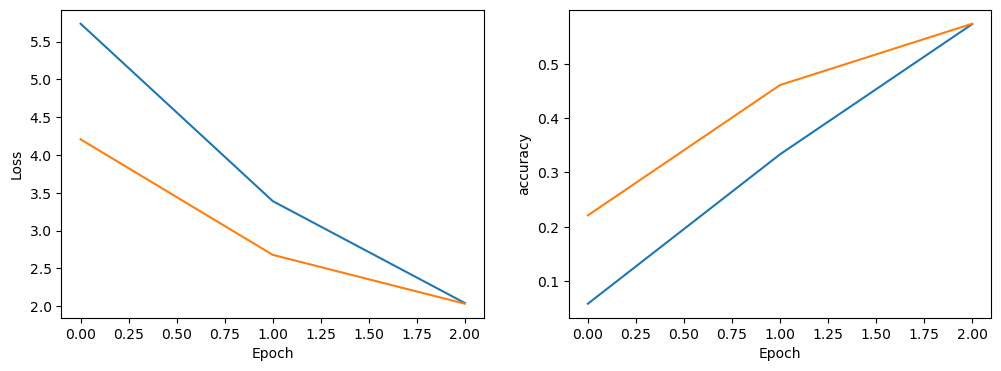

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.2863114010146324, accuracy = 0.7233229503931544
Val: loss = 1.7631257797809357, accuracy = 0.6248253245582401


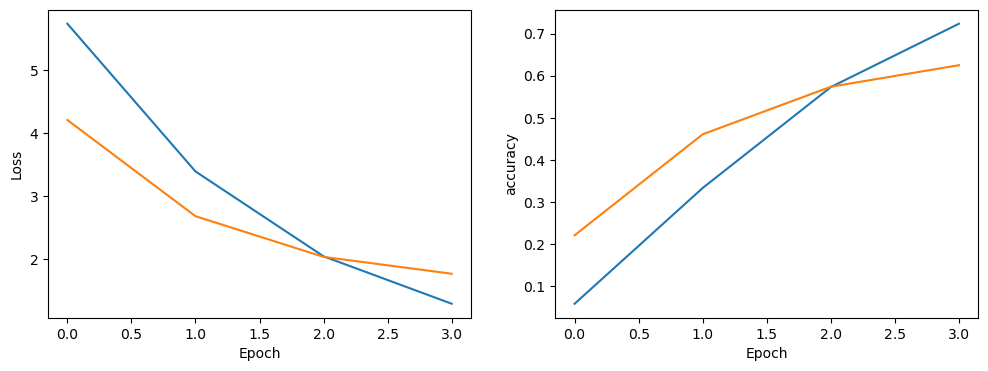

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.8806030411035457, accuracy = 0.8035606739515881
Val: loss = 1.5521724921591737, accuracy = 0.6783915209159754


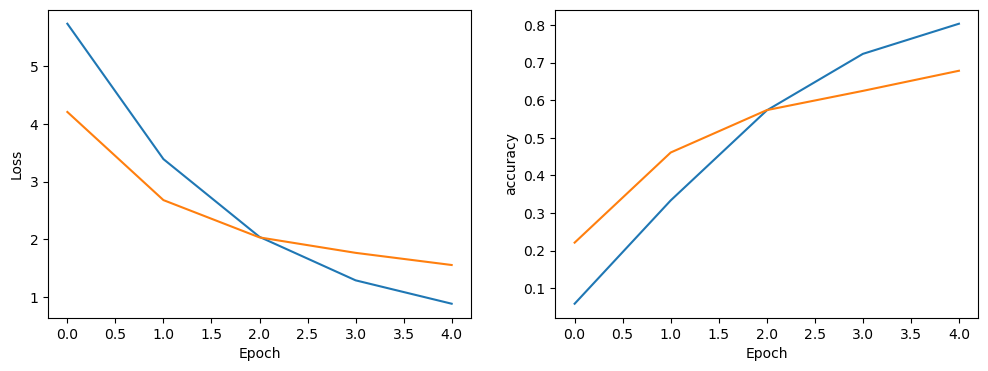

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.5911256805696385, accuracy = 0.865698114207524
Val: loss = 1.3579968898854358, accuracy = 0.7215419897223224


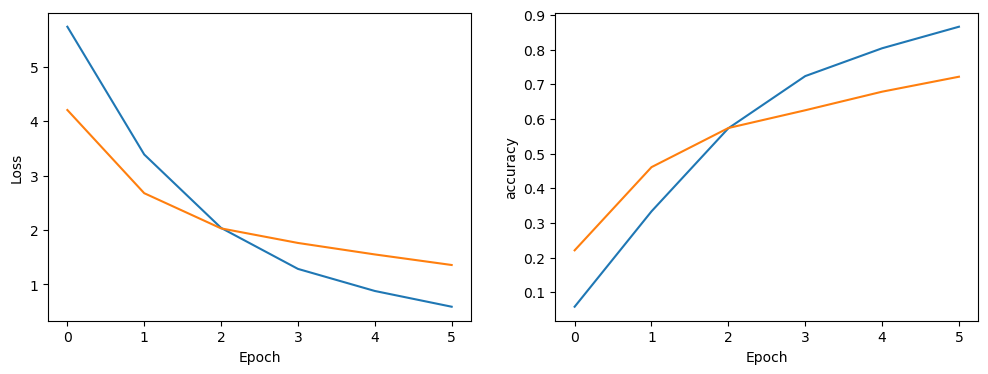

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.41445428878068924, accuracy = 0.9045233242753624
Val: loss = 1.3787811753597665, accuracy = 0.7119714659213848


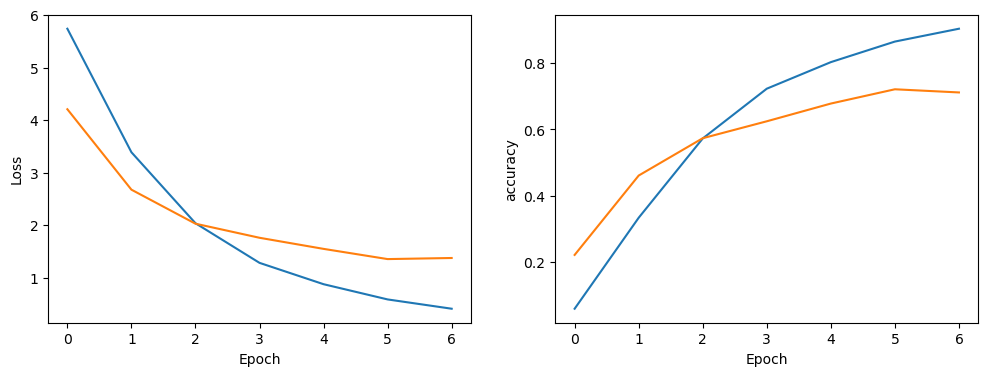

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.30408998642196045, accuracy = 0.9287678509481961
Val: loss = 1.3834325037104018, accuracy = 0.7234662369275153


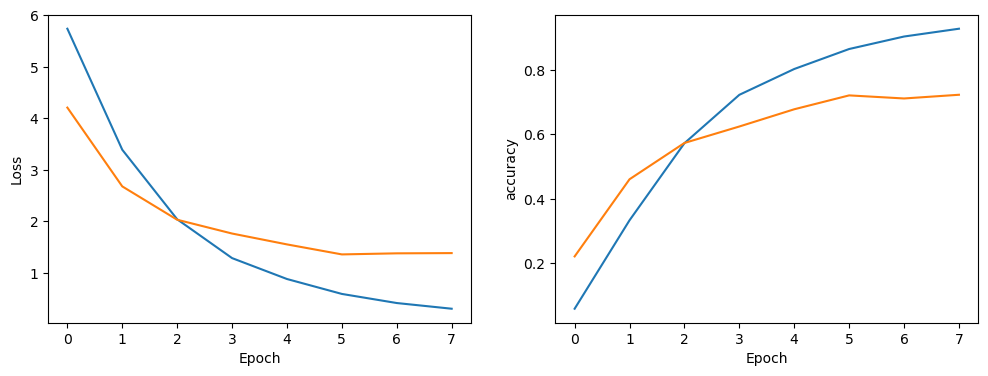

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.22574058266237695, accuracy = 0.9462628642460685
Val: loss = 1.4485485667878009, accuracy = 0.7122193923548503


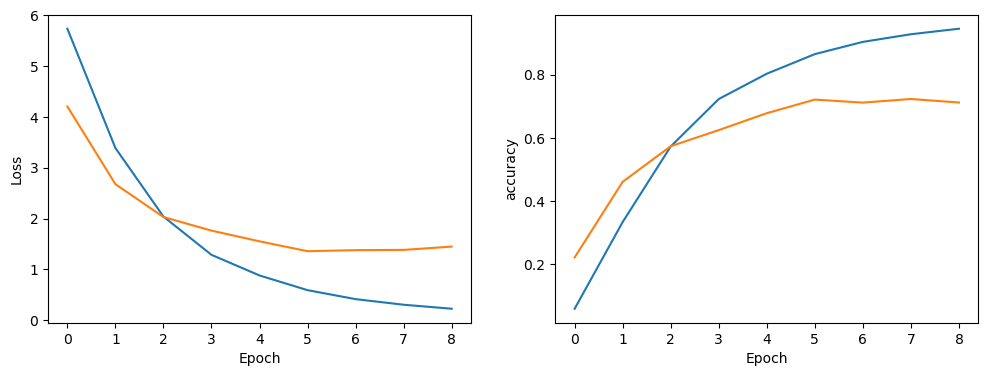

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.1864771671751712, accuracy = 0.9562778243524515
Val: loss = 1.3779977674179889, accuracy = 0.7331635412910206


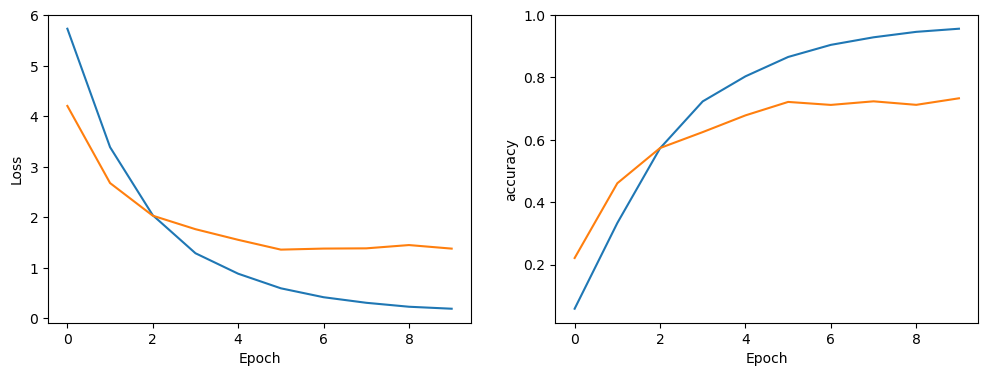

Best epoch = 9, <function accuracy at 0x0000024B2918F6A0> = 0.7331635412910206


In [ ]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_7')

Сохраним этот вариант

<h2>ResNet50</h2>

Используем улучшения, которые помогли resnet 18 (батчнорм, количество классов 1000) на resnet 50

<h3>Попытка 1</h3>

In [106]:
resnet_50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

resnet_50.fc = nn.Sequential(
    nn.BatchNorm1d(2048),  
    nn.Dropout(0.5),
    nn.Linear(2048, 1000)
)

for param in resnet_50.parameters():
    param.requires_grad = False

for param in resnet_50.layer3.parameters():
    param.requires_grad = True

for param in resnet_50.layer4.parameters():
    param.requires_grad = True

for param in resnet_50.fc.parameters():
    param.requires_grad = True

resnet_50 = resnet_50.to(device)

In [107]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_50.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #0
Train: loss = 5.732319864820926, accuracy = 0.06232112916281221
Val: loss = 4.801207339510005, accuracy = 0.1289527362062748


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.2165603067012545, accuracy = 0.32986191412272586
Val: loss = 2.7980237514414688, accuracy = 0.41796734132708263


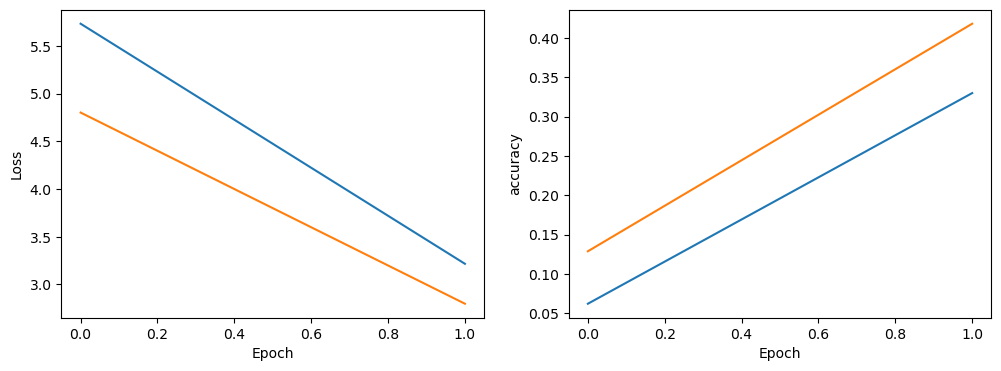

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #2
Train: loss = 1.7605716643181253, accuracy = 0.6068069688559975
Val: loss = 2.166404587157229, accuracy = 0.5412543950595023


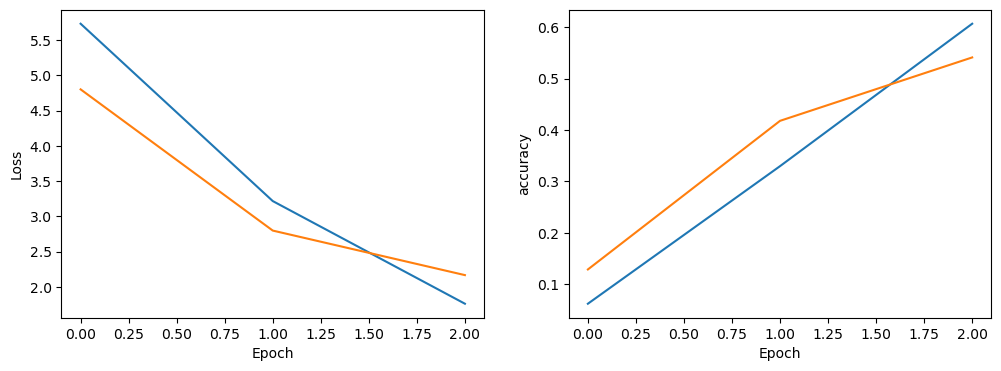

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.028388611813809, accuracy = 0.7645638201510947
Val: loss = 1.8097565123375425, accuracy = 0.6221234899026326


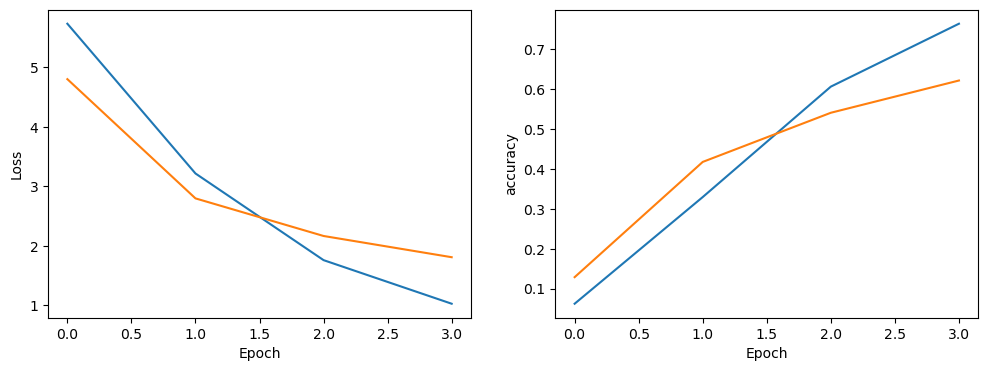

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.6073769426092188, accuracy = 0.8566804945266728
Val: loss = 1.602692423982823, accuracy = 0.6716580643707176


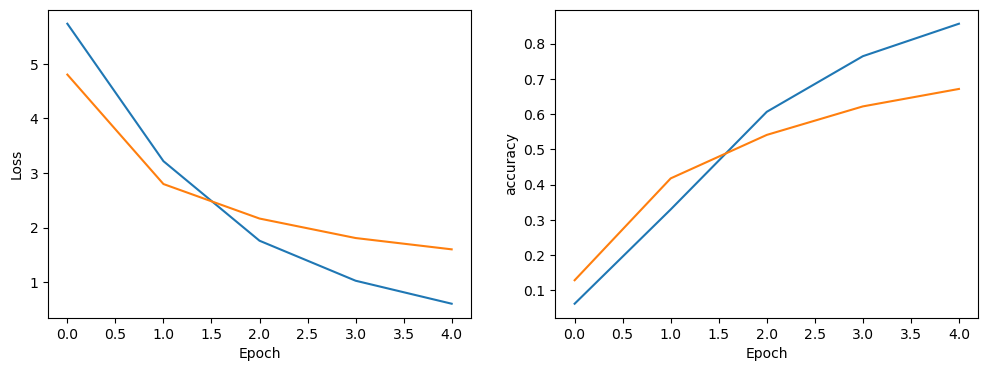

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.36261242612245237, accuracy = 0.9128338922294172
Val: loss = 1.7597361574781702, accuracy = 0.6559513613415074


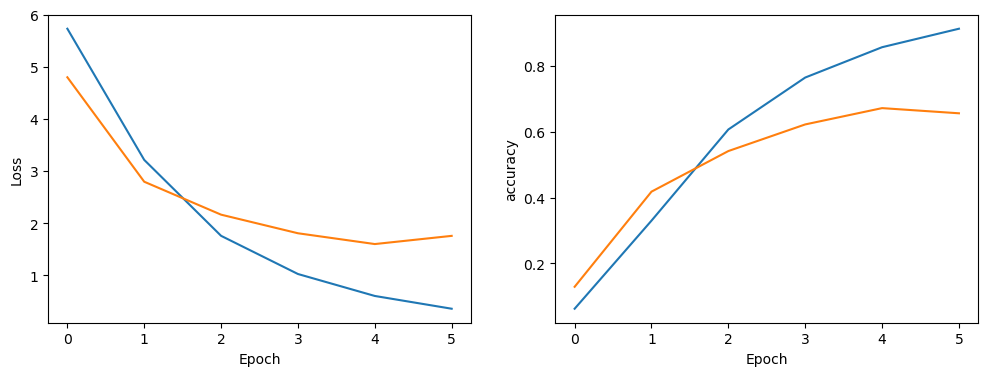

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.23749339196117633, accuracy = 0.9421669027520815
Val: loss = 1.5360662937164307, accuracy = 0.7022741615578796


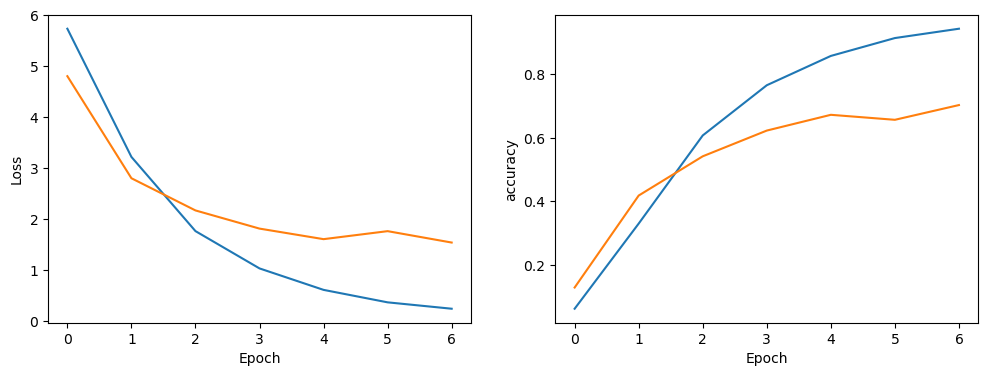

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.16567525115022633, accuracy = 0.9588837977952513
Val: loss = 1.4478504822609273, accuracy = 0.7331353678326722


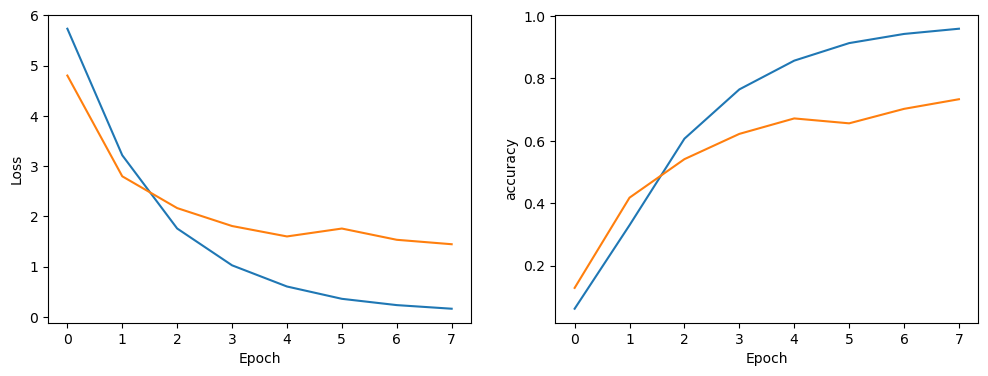

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.13768276510799818, accuracy = 0.9673786569148937
Val: loss = 1.5583492339925562, accuracy = 0.7161664938694555


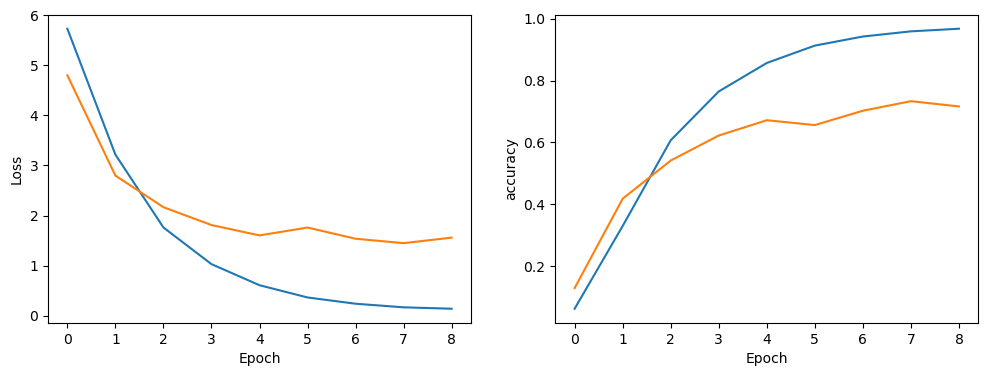

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.1264151866210902, accuracy = 0.9690589587187789
Val: loss = 1.5418928925027238, accuracy = 0.7257116615578796


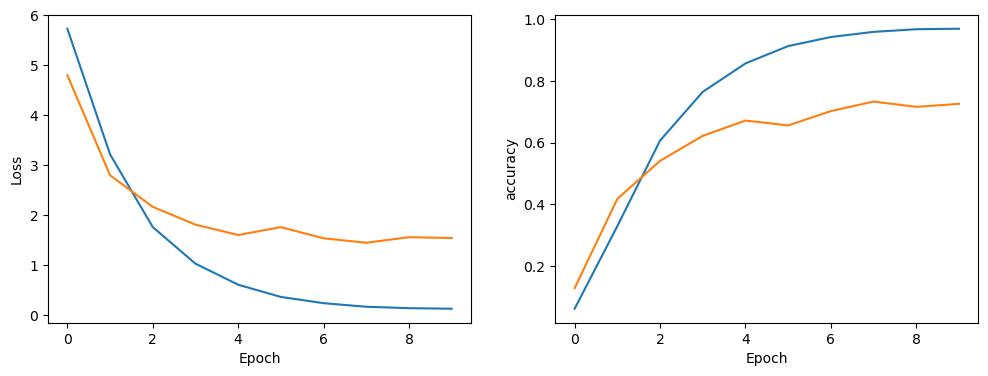

Best epoch = 7, <function accuracy at 0x0000024B2918F6A0> = 0.7331353678326722


In [108]:
resnet_50, resnet50_stats = train(resnet_50, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet50_CE', scheduler, '_atempt_1')

<h3>Попытка 2</h3>

Разморозим ещё один слой

In [ ]:
resnet_50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

resnet_50.fc = nn.Sequential(
    nn.BatchNorm1d(2048),  
    nn.Dropout(0.5),
    nn.Linear(2048, 1000)
)

for param in resnet_50.parameters():
    param.requires_grad = False

for param in resnet_50.layer2.parameters():
    param.requires_grad = True

for param in resnet_50.layer3.parameters():
    param.requires_grad = True

for param in resnet_50.layer4.parameters():
    param.requires_grad = True

for param in resnet_50.fc.parameters():
    param.requires_grad = True

resnet_50 = resnet_50.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_50.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [ ]:
resnet_50, resnet50_stats = train(resnet_50, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet50_CE', scheduler, '_atempt_2')